Author: Daniel Abadjiev  
Date: October 2, 2026  
Description: A notebook to test out things and try to do a cut based analysis matching Angira's

In [4]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#perhaps add 0.9806268960028482 SE to target efficiencies.. 
sys.path.append("../../daniel/validationPlots")
import plotUtils
import matplotlib
from pathlib import Path
# from plot_hit_time import *
###################################################
# sys.path.append("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/")
# from plotUtils import load_parquet_pairs, countBibSig, plotManyHisto
#instead of importing from plot_hit_time, copied and made edits
matplotlib.rcParams["figure.dpi"] = 300
STYLESHEET = "seaborn-v0_8-poster"

matplotlib.rcParams["figure.dpi"] = 300
matplotlib.pyplot.rcParams["patch.linewidth"] = 2
plt.style.use(STYLESHEET)

pklPath = "/local/d1/smartpixML/cutAnalysis/dfOfTruth.pkl"
pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/savedPklsFromFullDataset/dfOfTruth.pkl" #okay timing distribution
pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/plots/dfOfTruth.pkl" #messed up timing distribution
# pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_20260129_155514/plots/dfOfTruth.pkl"
# pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_20260119_151558/plots/dfOfTruth.pkl"
# pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_20260129_200531/plots/dfOfTruth.pkl"
# --- Load data ---
print(f"Loading truthDF from {pklPath}")
truthDF = pd.read_pickle(pklPath)

# --- Split into sig / bib sub-groups ---
fracBib, fracSig, fracMM, fracMP, numTotalSig, numTotalBib, truthSig, truthBib_mm, truthBib_mp, truthBib = plotUtils.countBibSig(truthDF, doPrint=True)


Loading truthDF from /home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/plots/dfOfTruth.pkl
len truthSig: 1717087
len truthBib: 1656656
len truthBib_mm: 837532
len truthBib_mp: 819124
fraction of total that are MM: 0.24825008899610906
fraction of total that are MP: 0.24279383462225784
fraction of total that are Bib: 0.4910439236183669
fraction of total that are Sig: 0.5089560763816331


In [32]:
predVarDf = pd.read_pickle("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/paperPlots/evaluationPlots/mdl_al_1046.h5/predVarDF.pkl")
# plt.hist(truthBib["z-global"])
# plt.show()
predVarDf
bibVarDF = predVarDf.query("trueY==0");sigVarDF = predVarDf.query("trueY==1")
bibVarDF

,xSize,ySize,nModule,x_local,y-local,z-global,nPix,pt,adjusted_hit_time_30ps_gaussian,prediction,trueY,eta
2,2.0,2.0,0.6,0.838461,-6.275,49.899998,4.0,0.00087,-0.216366,0.000000,0.0,1.282079
3,14.0,8.0,-0.6,0.596154,-0.025,-31.250000,22.0,0.00145,0.990682,0.000000,0.0,-0.910532
4,2.0,6.0,-0.4,0.575000,-3.800,-18.525000,8.0,0.01512,1.138016,0.000000,0.0,-0.583773
5,2.0,2.0,0.2,0.136538,-6.825,14.775000,3.0,0.00050,-0.075634,0.808594,0.0,0.474494
7,1.0,4.0,0.8,0.634616,3.775,60.250000,4.0,0.01248,1.085824,0.000000,0.0,1.447356
...,...,...,...,...,...,...,...,...,...,...,...,...
660616,2.0,5.0,-0.2,0.478846,-3.525,-6.775000,7.0,0.01438,1.203529,0.000000,0.0,-0.223956
660620,2.0,2.0,0.2,0.413462,1.200,18.375000,4.0,0.02265,1.983477,0.843750,0.0,0.579514
660621,7.0,8.0,-1.0,0.813461,-4.450,-54.425003,15.0,0.00045,0.022853,0.000000,0.0,-1.357300
660624,3.0,2.0,-0.8,0.294231,-7.225,-48.174999,5.0,0.00548,1.028021,0.000000,0.0,-1.252071


(array([[0.0000e+00, 4.2010e+03, 7.8970e+03, 1.0140e+03, 8.0000e+01,
         1.0000e+01, 6.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00],
        [4.1000e+02, 9.2100e+03, 9.4720e+03, 2.1800e+02, 3.6000e+01,
         1.1000e+01, 1.0000e+01, 4.0000e+00, 1.0000e+00, 0.0000e+00],
        [7.4710e+03, 1.7085e+04, 4.9360e+03, 5.3000e+01, 1.7000e+01,
         1.2000e+01, 4.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.5359e+04, 1.7975e+04, 5.3900e+02, 3.0000e+01, 2.1000e+01,
         9.0000e+00, 1.0000e+01, 2.0000e+00, 1.0000e+00, 0.0000e+00],
        [4.7763e+04, 1.0755e+04, 1.4500e+02, 1.9000e+01, 1.9000e+01,
         0.0000e+00, 5.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [4.7681e+04, 1.1117e+04, 1.7400e+02, 3.1000e+01, 1.7000e+01,
         2.0000e+00, 3.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.5635e+04, 1.7895e+04, 5.8600e+02, 2.4000e+01, 2.0000e+01,
         7.0000e+00, 6.0000e+00, 3.0000e+00, 2.0000e+00, 0.0000e+00],
        [7.4570e+03, 1.7460

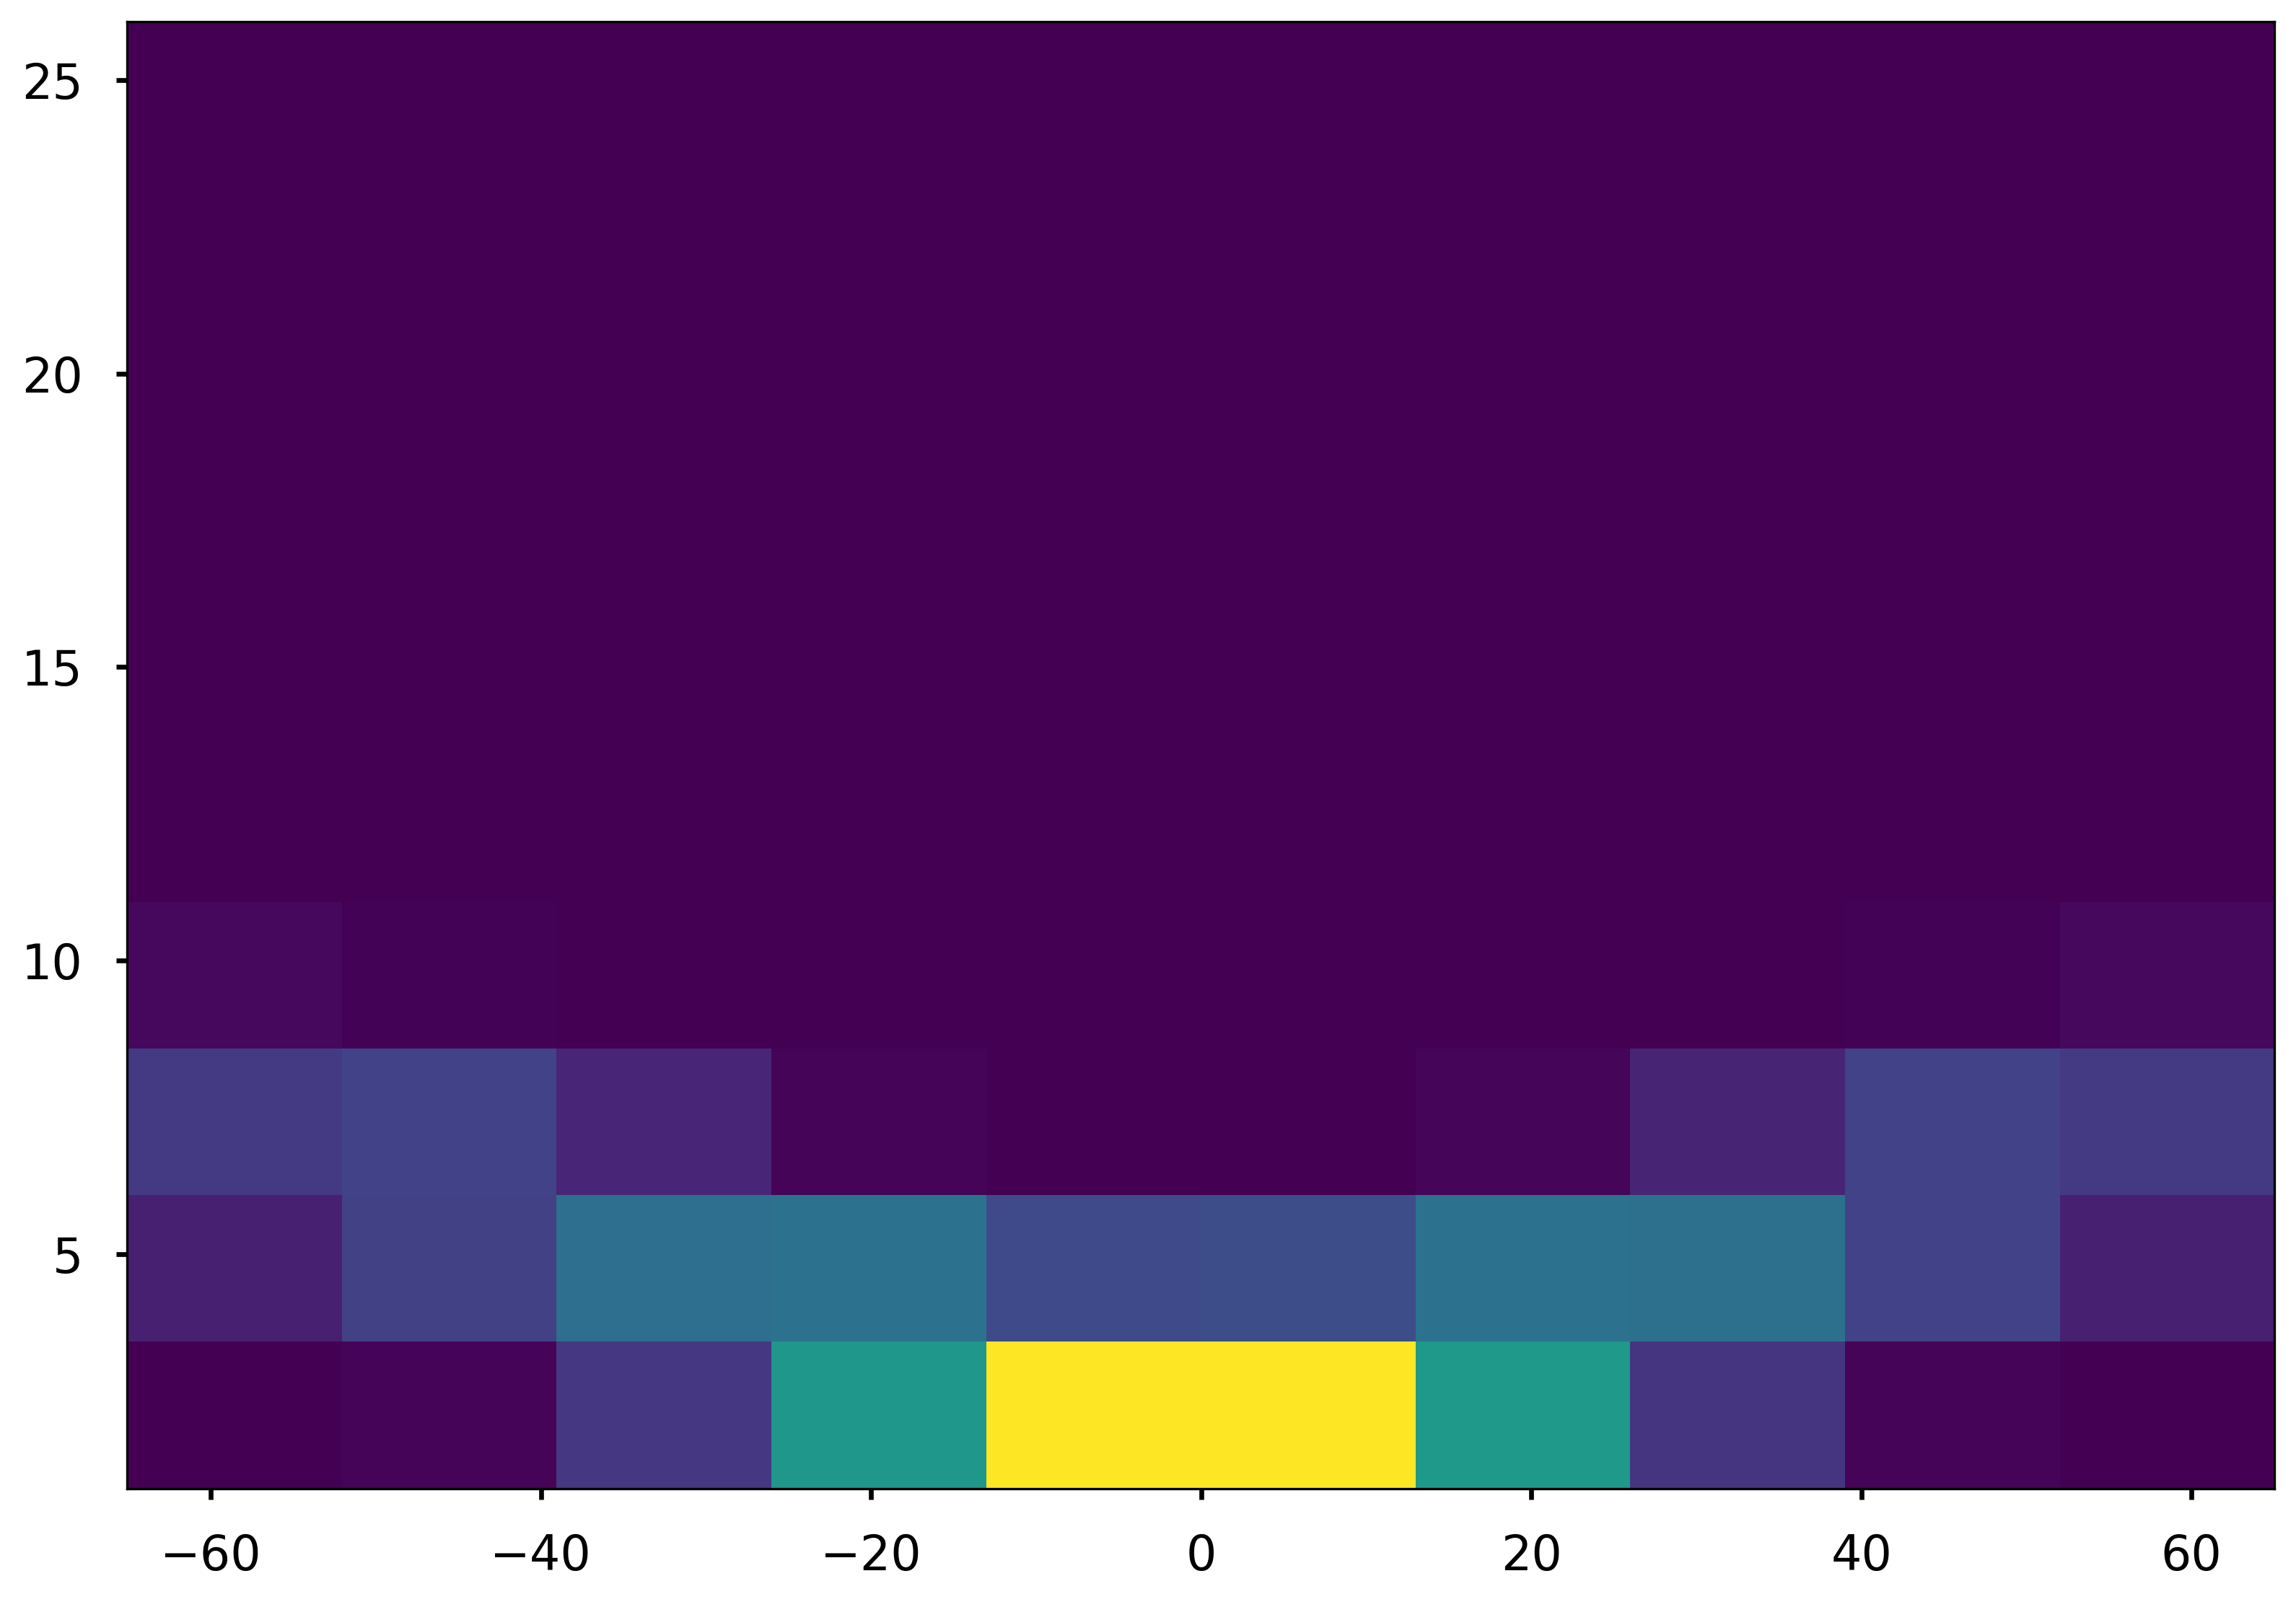

In [33]:
plt.hist2d(bibVarDF["z-global"],bibVarDF["nPix"])
plt.hist2d(sigVarDF["z-global"],sigVarDF["nPix"])

In [20]:
import os
import sys
sys.path.append("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots")
from SpixPlotter import SmartpixPlotter
import argparse
from pathlib import Path
import matplotlib
import plotUtils
import numpy as np
###########################################################################
########## Defaults for data directories, copied from runPlots2.py
repodir = Path("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels")
print("Assuming you are starting in .....paperPlots, so git repo dir is ", repodir)
assert repodir.parts[-1] == 'Muon_Collider_Smart_Pixels'
dataDir_all = "Data_Set_2026Feb"
if dataDir_all is not None:
    print("Using a dataset directory with subfolders, following Eliza's 2026 dataset format, ignoring other directories")
    print("Setting plot directory inside dataset folder")
    #either dataDir_all is a string witht the dataset name, in which case join paths from DataFiles and repodir
    #otherwise, dataDir_all should be an absolute path to the dataset
    # if 
    datasetPath = Path(dataDir_all)
    if len(datasetPath.parts) == 1:
        print("looking for the dataset in Data_Files")
        datasetDir = repodir.joinpath("Data_Files").joinpath(datasetPath)
    else:
        print("assuming dataset passed is in an absolute path")
        datasetDir = datasetPath
    parquetDir_all = datasetDir.joinpath("Parquet_Files")
    trackDirBib_mm = datasetDir.joinpath("Track_Lists")
    trackDirBib_mp = datasetDir.joinpath("Track_Lists")
    trackDirSig = datasetDir.joinpath("Track_Lists")
    # PLOT_DIR = datasetDir.joinpath("plots")
###########################################################################

STYLESHEET = "seaborn-v0_8-colorblind"
STYLESHEET = "seaborn-v0_8-poster"

matplotlib.rcParams["figure.dpi"] = 300
matplotlib.pyplot.rcParams["patch.linewidth"] = 2


def getSpixPlotter(parquetDir_all = "/local/d1/smartpixML/bigData/allData/",     #this should be not used?          
            #skip_indices = list(range(1730 - 124+87, 1769)),
            trackDirBib_mm = trackDirBib_mm,
            trackDirBib_mp = trackDirBib_mp,
            trackDirSig = trackDirSig,
            processRecon = False,
            interactivePlots = False,
            PLOT_DIR = "../datasetPlots",
            savedPklFromParquet = True,
            processTracks = True,
            processOldTracks = False,
            plotTracklists = True,
            plotParquets = True,
            styleSheet=STYLESHEET,):
    plotter = SmartpixPlotter(
                    #  parquetDir_mm = parquetDir_mm , #Not yet implemented
                    #  parquetDir_mp = parquetDir_mp ,
                    #  parquetDir_sig = parquetDir_sig ,
                    parquetDir_all = parquetDir_all ,
                    skip_indices = None,#list(range(1730 - 124+87, 1769)),
                    trackDirBib_mm = trackDirBib_mm,
                    trackDirBib_mp = trackDirBib_mp,
                    trackDirSig = trackDirSig,
                    processRecon = processRecon,
                    interactivePlots=interactivePlots,
                    PLOT_DIR = PLOT_DIR,# os.path.join(os.path.dirname(os.path.abspath(__file__)), "plots"),
                    savedPklFromParquet = savedPklFromParquet,
                    processTracks = processTracks,
                    processOldTracks = processOldTracks,
                    plotTracklists = plotTracklists,
                    plotParquets = plotParquets,
                    styleSheet = styleSheet,
                    )
    # plotter.runPlots()
    return plotter

Assuming you are starting in .....paperPlots, so git repo dir is  /home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels
Using a dataset directory with subfolders, following Eliza's 2026 dataset format, ignoring other directories
Setting plot directory inside dataset folder
looking for the dataset in Data_Files


In [ ]:
plotter = getSpixPlotter()

loading data, Currently loading settings: 
processRecon: False
savedPklFromParquet: True
interactivePlots: False
[    488     489     490 ... 3119334 3119335 3119336]
len truthSig: 1600000
len truthBib: 1600000
len truthBib_mm: 809783
len truthBib_mp: 790217
fraction of total that are MM: 0.2530571875
fraction of total that are MP: 0.2469428125
fraction of total that are Bib: 0.5
fraction of total that are Sig: 0.5
Finished loading parquet data [not counting tracks], now proceeding to plotting or tracklists
Start loading track data
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/Track_Lists
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/Track_Lists
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/Track_Lists
Loaded tracks with counting of 
 bib mm: 875437 
 bib mp: 856000  
 bib total: 1731437 
 Signal: 1750000 
Nan m count: 0
Nan m count: 0

In [16]:
def ploCutCount2dDist(truthBib: pd.DataFrame,truthSig:pd.DataFrame,cut:str=None,plotZgXs=False,plotEtXs=False,plotNpEt=True):
    """
    Applies the cut in the parameter to each dataframe, then plots the 2d histograms of
         zglobal vs. xsize, eta vs. xsize, or nPix vs. eta as specified
    Counts the length of the truthBib and truthSig before and after
    """
    # mask_bib,mask_sig,mask_bib_x,mask_sig_x,mask_bib_y,mask_sig_y, = plotUtils.getEricsMasks(plotter.truthBib, plotter.truthSig, plotter.xSizesSig, plotter.xSizesBib, plotter.ySizesSig, plotter.ySizesBib,)
    
    if cut is not None:
        truthBib = truthBib.query(cut); truthSig = truthSig.query(cut)
    
    mask_bib = [True for _ in truthBib["z-global"]]
    mask_sig = [True for _ in truthSig["z-global"]]
    if plotZgXs:
        plotUtils.plot1by2BibSig2dHisto(truthBib,truthSig,'z-global', 'xSize',mask_bib,mask_sig,30,np.arange(0,22,1),"Blues",
                                r'$z_{\mathrm{global}}$ [mm]',r'$x_{\mathrm{size}}$ [# pixels]', "bib_signal_zglobal_vs_xsize_comparison",
                                plotter.PLOT_DIR,True,logColor=True,colorLabel=r"$n_{\mathrm{clusters}}$")
    if plotEtXs:
        plotUtils.plot1by2BibSig2dHisto(truthBib,truthSig,'eta', 'xSize',mask_bib,mask_sig,30,np.arange(0,22,1),"Blues",
                                r'$\eta$ ',r'$x_{\mathrm{size}}$ [# pixels]', "bib_signal_zglobal_vs_xsize_comparison",
                                plotter.PLOT_DIR,True,logColor=True,colorLabel=r"$n_{\mathrm{clusters}}$")
    if plotNpEt:
        plotUtils.plot1by2BibSig2dHisto(truthBib,truthSig,'eta', 'nPix',mask_bib,mask_sig,30,np.arange(0,22,1),"Blues",
                                r'$\eta$ ',r'$n_{\mathrm{pix}}$ [# pixels]', "bib_signal_zglobal_vs_xsize_comparison",
                                "./haha",True,logColor=True,colorLabel=r"$n_{\mathrm{clusters}}$")
    print("cut: ",cut)
    numBib=len(truthBib);numSig=len(truthSig)
    print("number BIB clusters ",numBib,"number of signal clusters ",numSig)
    fracBib=len(truthBib)/len(plotter.truthBib);fracSig=len(truthSig)/len(plotter.truthSig)
    print("fraction of total bib ",fracBib," fraction of total signal ",fracSig,)
    return numBib, numSig,fracBib,fracSig
    # plotUtils.plot1by2BibSig2dHisto(plotter.truthBib,plotter.truthSig,'z-global', 'xSize',mask_bib,mask_sig,30,np.arange(0,22,1),pastel_red_cmap,
    #                         r'$z_{\mathrm{global}}$ [mm]',r'$x_{\mathrm{size}}$ [# pixels]', "bib_signal_zglobal_vs_xsize_comparison",
    #                         PLOT_DIR,interactivePlots,logColor=True,colorLabel=r"$n_{\mathrm{clusters}}$")

In [7]:
plotter.truthBib

,x-entry,y-entry,z-entry,n_x,n_y,n_z,number_eh_pairs,y-local,z-global,pt,...,scalePion,p_calc1,p_calc2,p_calc3,betaGamma,pathLength,EHperMicron,xSize,ySize,nPix
0,12.612453,14.527484,0.0,-0.007871,-0.018733,0.062323,28409.0,-1.875,5.975000,0.00024,...,273.131115,0.00024,0.000242,0.000242,0.469669,52.590350,540.194160,2,1,2
1,29.066113,65.269089,0.0,0.036481,-0.130226,0.110756,5391.0,-2.350,4.775000,0.00063,...,273.131115,0.00064,0.000644,0.000644,1.252449,78.914174,68.314724,2,3,5
2,-44.518486,14.245097,0.0,0.057630,-0.088582,0.082119,9590.0,-2.450,4.750000,0.00044,...,273.131115,0.00049,0.000488,0.000488,0.958902,81.487791,117.686341,3,2,6
3,6.897231,23.592140,0.0,-0.093445,-0.085867,0.153784,6196.0,-3.250,5.975000,0.00064,...,273.131115,0.00073,0.000724,0.000724,1.428571,64.826519,95.578169,2,1,2
4,6.639468,-42.642422,0.0,-0.017276,0.102190,0.140767,7664.0,-3.100,6.025000,0.00064,...,273.131115,0.00064,0.000643,0.000643,1.252450,62.090005,123.433715,1,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462,-68.585068,-30.455032,0.0,0.575477,0.175158,0.449792,12871.0,-2.925,60.574998,0.00177,...,273.131115,0.00275,0.002754,0.002754,5.381604,83.495313,154.152366,3,2,6
463,-10.565133,62.961945,0.0,5.269325,-3.755303,3.062653,7275.0,1.800,-36.250002,0.01774,...,273.131115,0.02621,0.026207,0.026207,51.291581,116.871973,62.247602,3,2,8
464,29.091125,-40.341335,0.0,-4.269450,3.197529,2.917666,10542.0,-0.800,-19.324999,0.01585,...,273.131115,0.02226,0.022263,0.022263,43.561645,104.191138,101.179430,3,2,8
465,-43.689495,43.477692,0.0,4.254432,-3.025033,3.041487,8250.0,4.475,26.475000,0.01571,...,273.131115,0.02212,0.022126,0.022126,43.287672,99.320831,83.064146,3,2,6


In [25]:
# plt.hist2d(plotter.truthBib["z-global"],plotter.truthBib["xSize"])
# plt.hist2d(plotter.truthBib["eta"],plotter.truthBib["nPix"])
# plt.hist2d(plotter.truthSig["z-global"],plotter.truthSig["xSize"])
print(plotter.truthBib.keys())

Index(['x-entry', 'y-entry', 'z-entry', 'n_x', 'n_y', 'n_z', 'number_eh_pairs',
       'y-local', 'z-global', 'pt', 'hit_time', 'PID', 'cotAlpha', 'cotBeta',
       'y-midplane', 'x-midplane', 'adjusted_hit_time',
       'adjusted_hit_time_30ps_gaussian', 'adjusted_hit_time_60ps_gaussian',
       'source', 'eta', 'R', 'q', 'm', 'scalePion', 'p_calc1', 'p_calc2',
       'p_calc3', 'betaGamma', 'pathLength', 'EHperMicron', 'xSize', 'ySize',
       'nPix'],
      dtype='object')


In [44]:
print(np.max(plotter.truthSig["eta"]))

1.5164780151171064


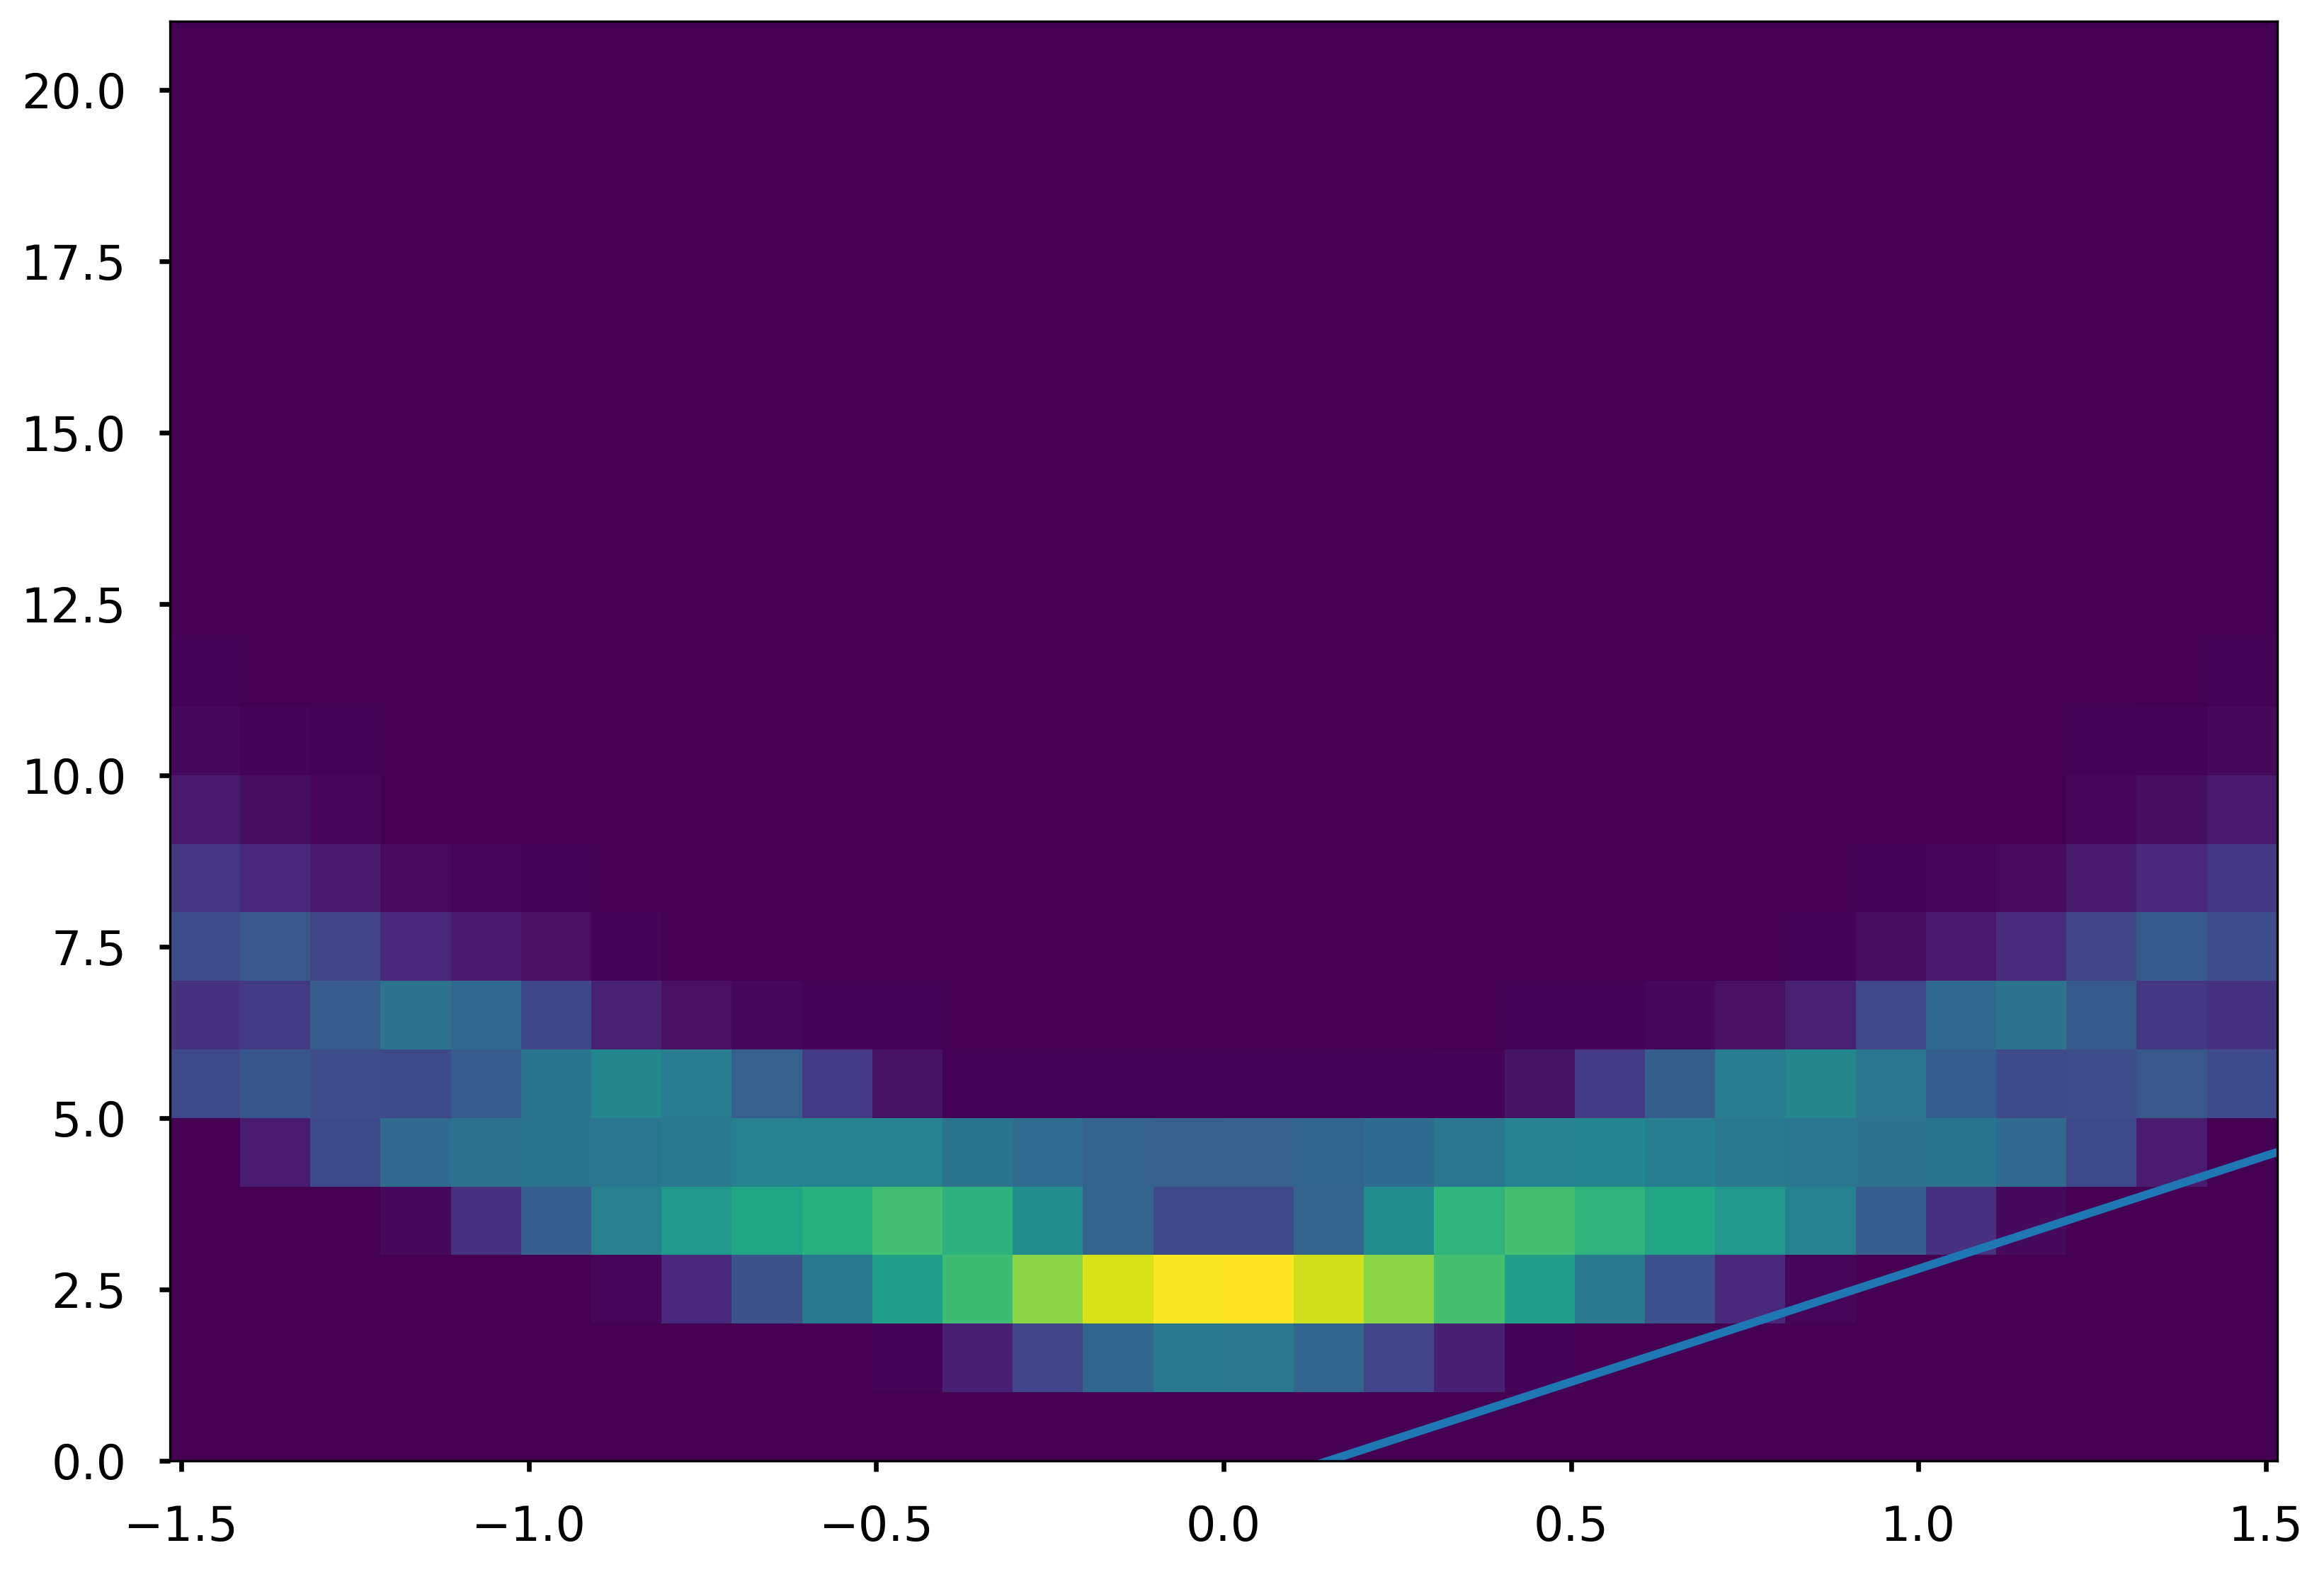

In [100]:
# plotter.truthBib.query("nPix<10")
plt.hist2d(plotter.truthSig["eta"],plotter.truthSig["nPix"],bins=(30,np.arange(0,22,1)))
sampleEtas = np.linspace(0,1.6,10)
plt.plot(sampleEtas,sampleEtas*5/1.516-0.5)
plt.show()

In [7]:
ploCutCount2dDist(plotter.truthBib,plotter.truthSig)
cut1="nPix < 10"
# truthBibCut1 = plotter.truthBib.query(cut1); truthSigCut1 = plotter.truthSig.query(cut1)
# print("done cutting")
ploCutCount2dDist(plotter.truthBib,plotter.truthSig,cut1)
cut2="(nPix < 10) and (nPix>(5/1.516)*eta) and (nPix>(-5/1.516)*eta)"
# cut2="(nPix < 10) and (nPix<5)"
# truthBibCut2 = plotter.truthBib.query(cut2); truthSigCut2 = plotter.truthSig.query(cut2)
ploCutCount2dDist(plotter.truthBib,plotter.truthSig,cut2)
cut3="(nPix < 10) and (nPix> (5/1.516)*eta - 1) and (nPix> (-5/1.516)*eta - 1)"
ploCutCount2dDist(plotter.truthBib,plotter.truthSig,cut3)

cut4="(nPix < 10) and (nPix> (5/1.5)*eta - 0.5) and (nPix> (-5/1.516)*eta - 0.5)"
ploCutCount2dDist(plotter.truthBib,plotter.truthSig,cut4)

cut5="(nPix> (5/1.5)*eta - 0.5) and (nPix> (-5/1.516)*eta - 0.5)"
ploCutCount2dDist(plotter.truthBib,plotter.truthSig,cut5)

# # plt.plot([1,2,3])

NameError: name 'plotter' is not defined

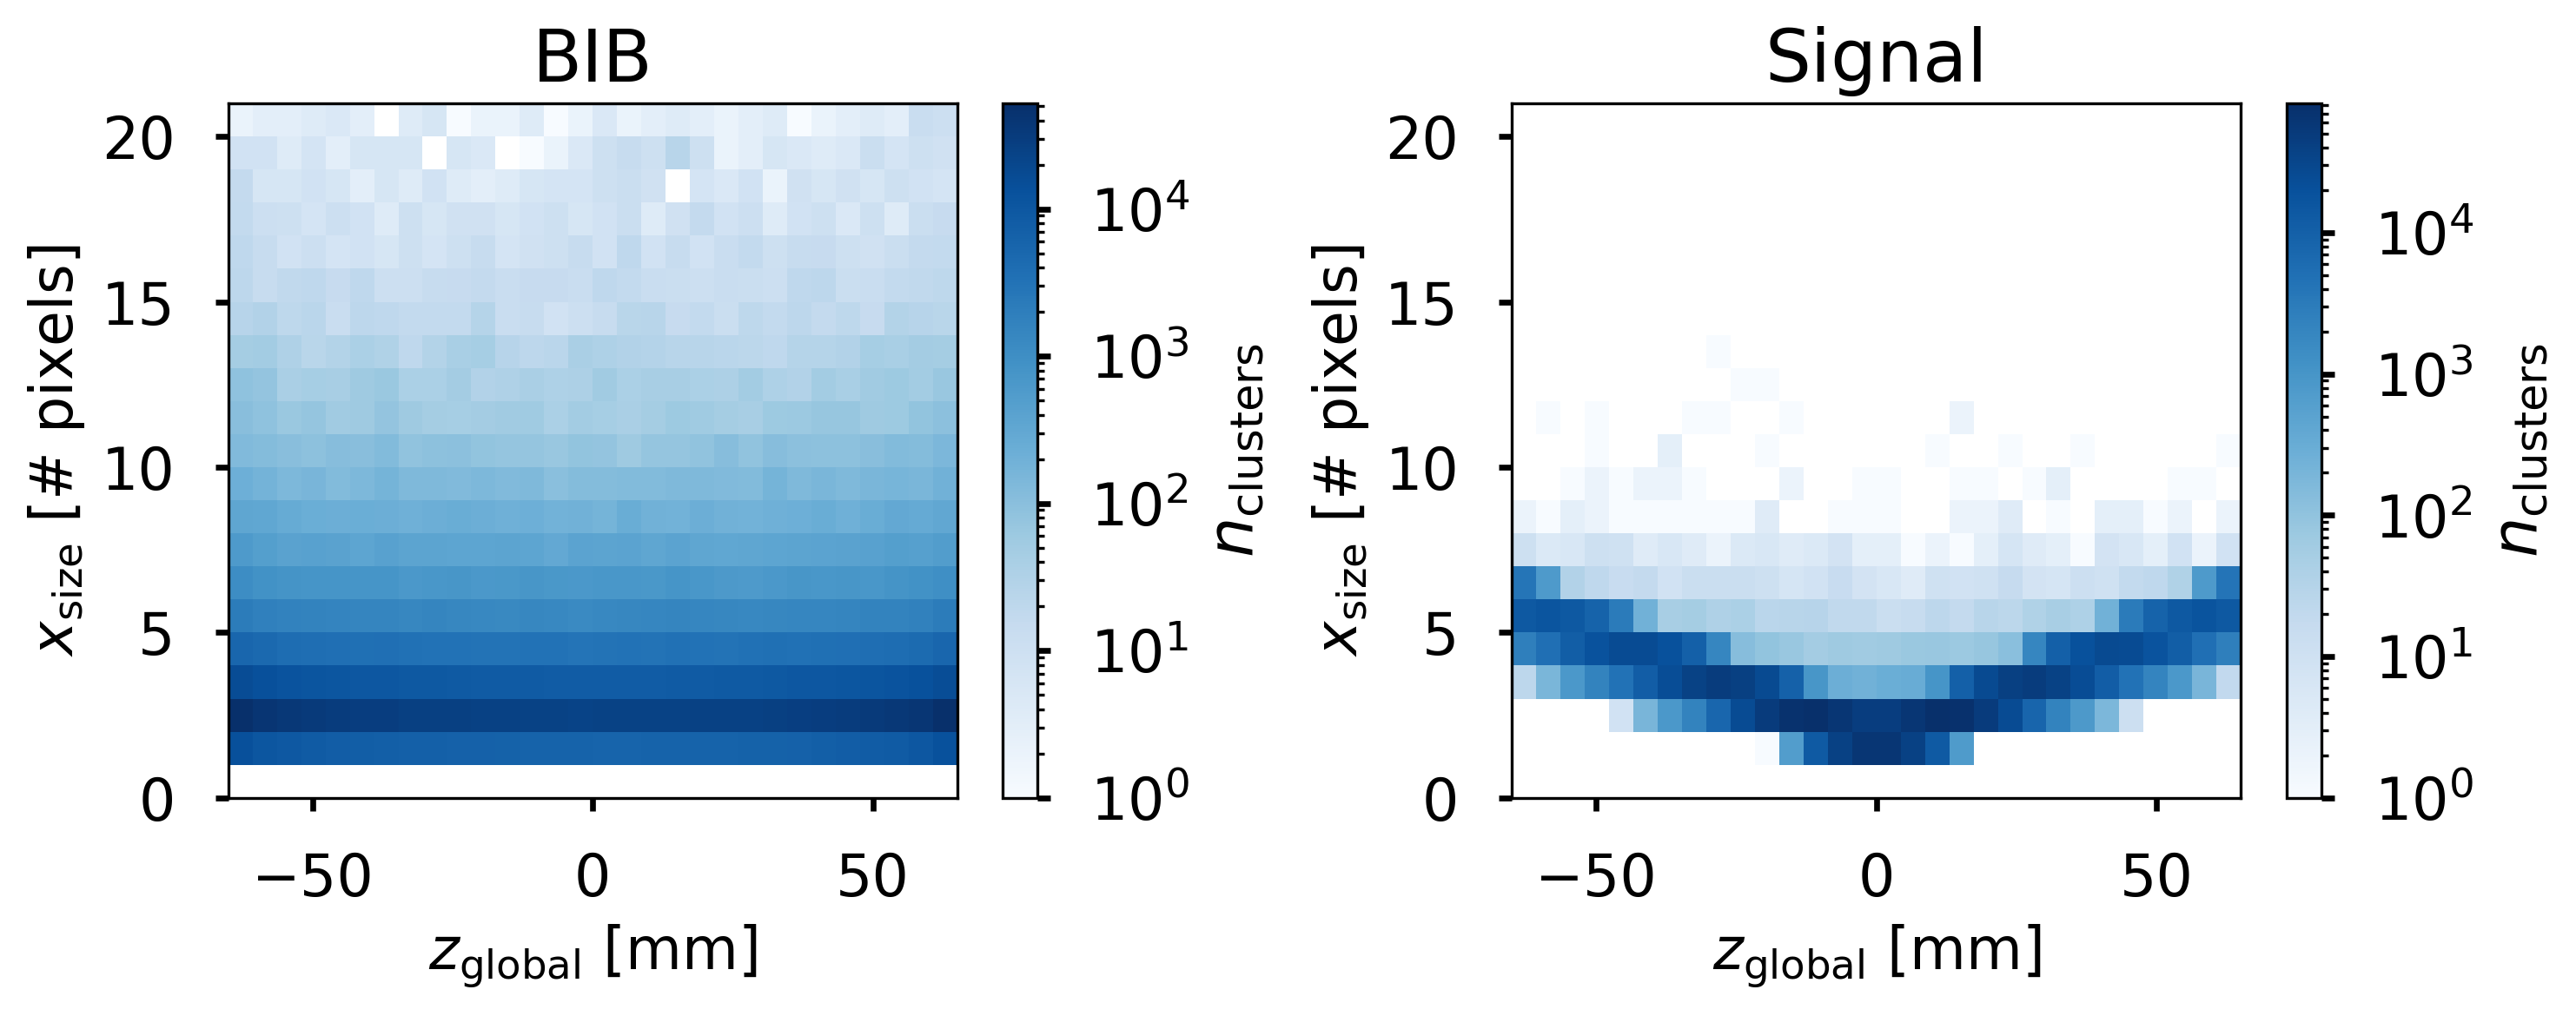

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  None
number BIB clusters  1656656 number of signal clusters  1717087
fraction of total bib  1.0  fraction of total signal  1.0


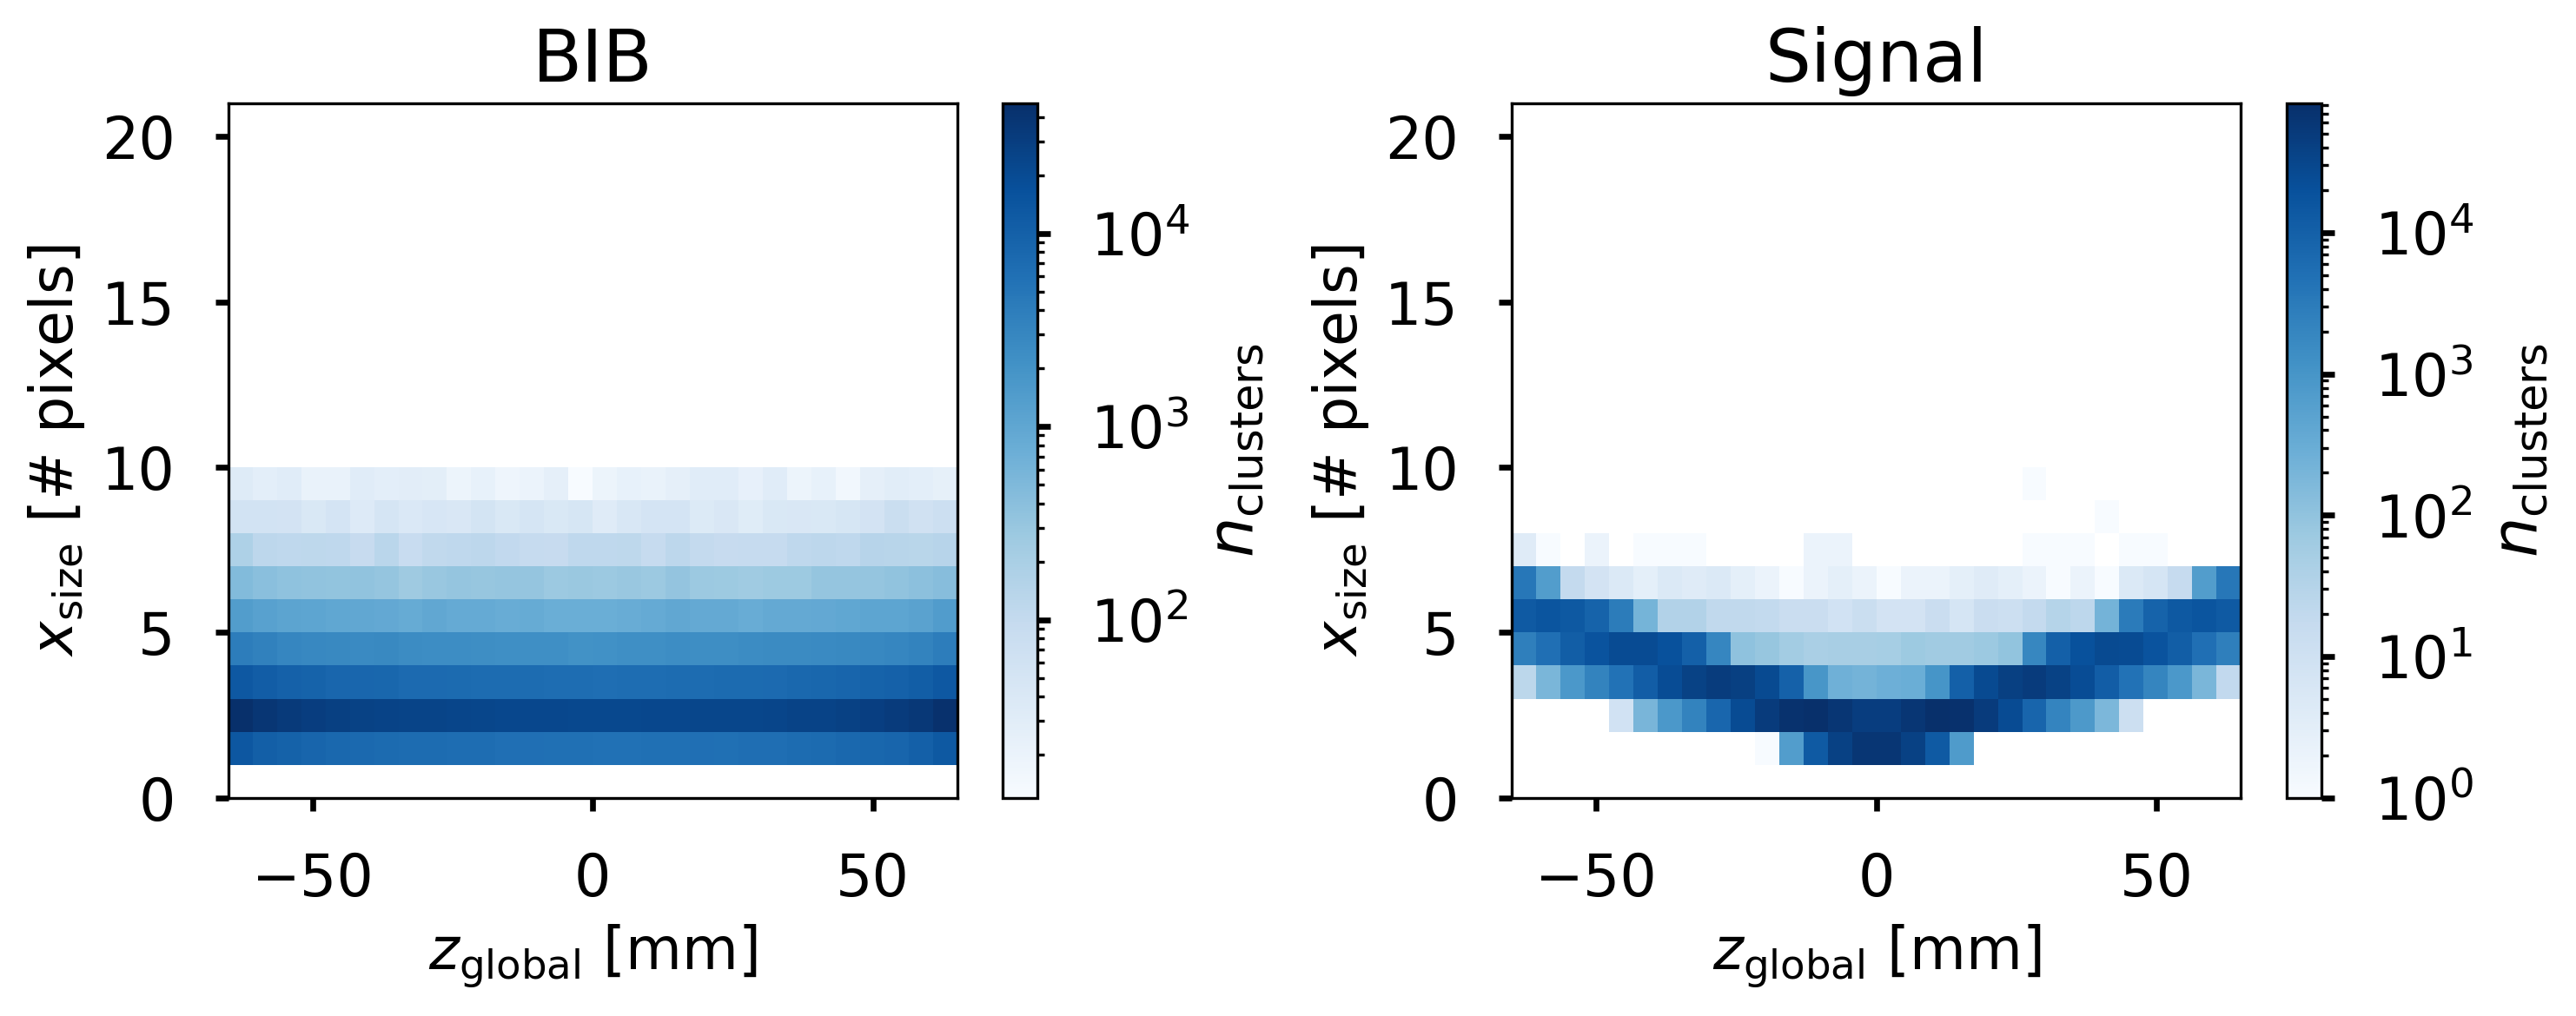

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  nPix < 10
number BIB clusters  1424631 number of signal clusters  1710524
fraction of total bib  0.8599437662375291  fraction of total signal  0.9961778290791323


In [ ]:
ploCutCount2dDist(plotter.truthBib,plotter.truthSig,plotZgXs=True,plotNpEt=False)
cut1="nPix < 10"
# truthBibCut1 = plotter.truthBib.query(cut1); truthSigCut1 = plotter.truthSig.query(cut1)
# print("done cutting")
ploCutCount2dDist(plotter.truthBib,plotter.truthSig,cut1,plotZgXs=True,plotNpEt=False)

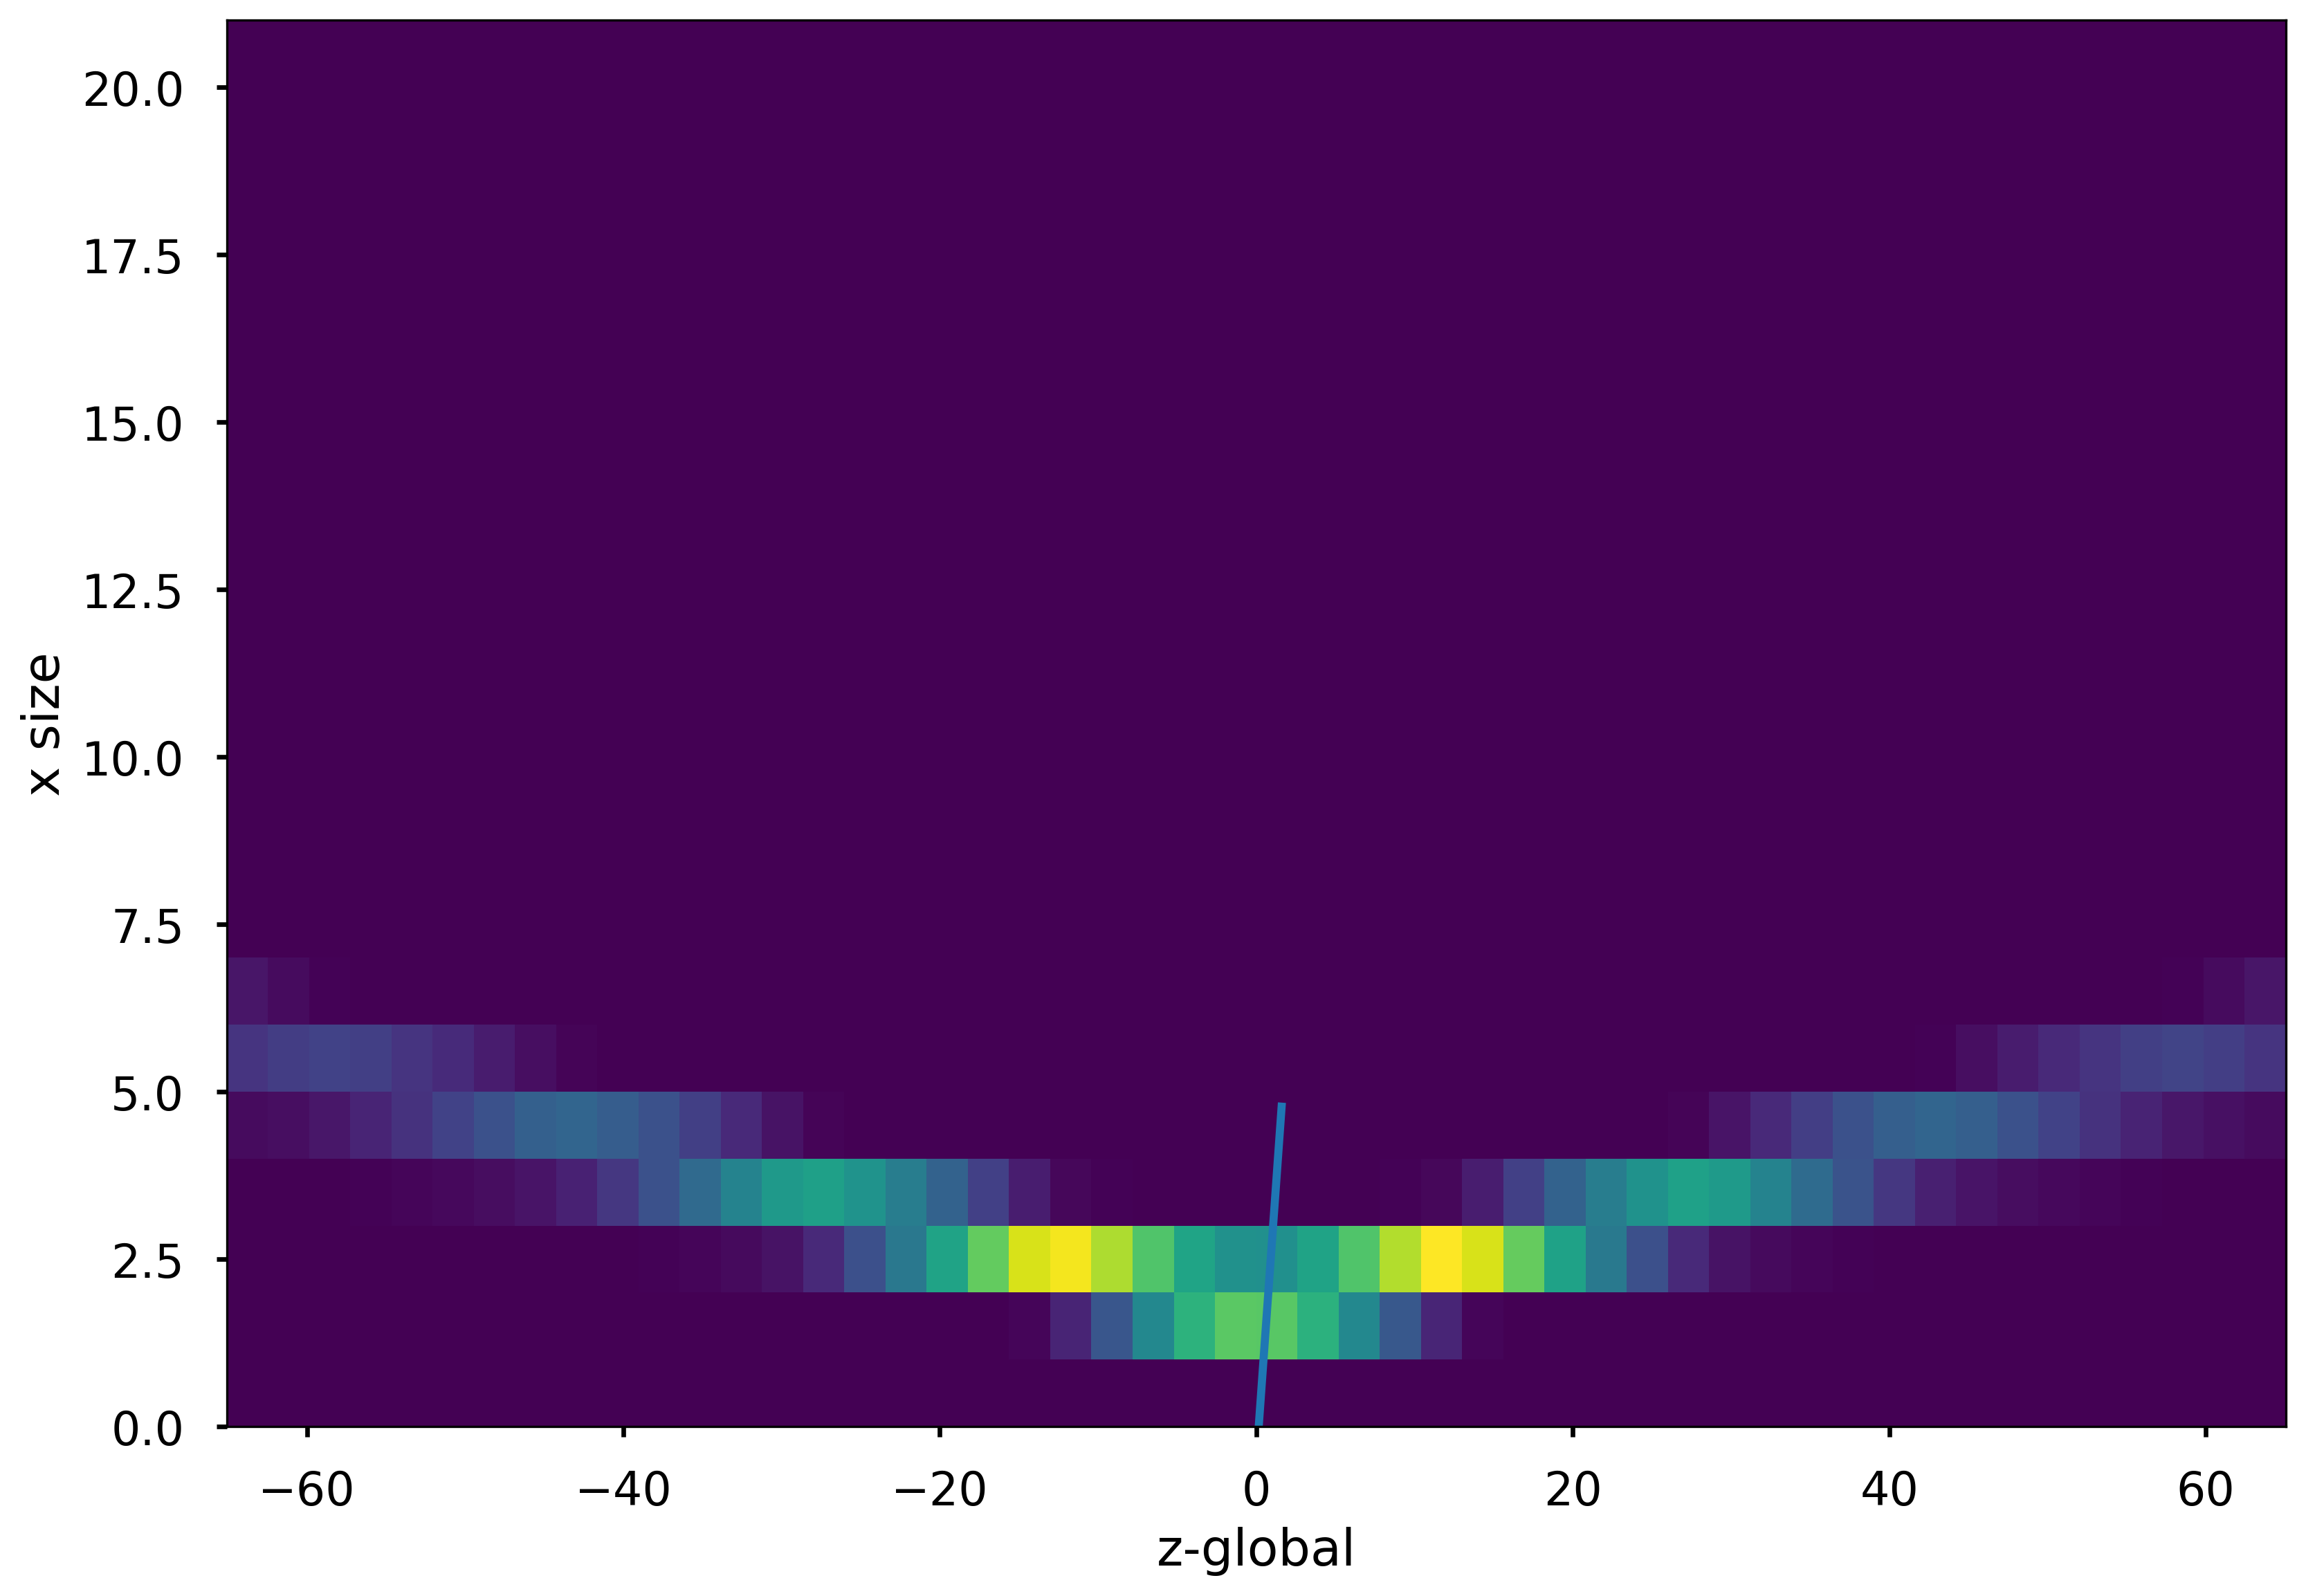

In [98]:
plt.hist2d(plotter.truthSig["z-global"],plotter.truthSig["xSize"],bins=(50,np.arange(0,22,1)))
plt.xlabel("z-global");plt.ylabel("x size")
sampleEtas = np.linspace(0,1.6,10)
plt.plot(sampleEtas,sampleEtas*5/1.516-0.5)
plt.show()

## More nicer systematic way of doing things

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
def abs_model(z, a, b):
    return a * np.abs(z) + b
def first_nonzero_xsize(col_counts, xsize_centers):
    nonzero_idx = np.nonzero(col_counts)[0]
    return xsize_centers[nonzero_idx[0]] if len(nonzero_idx) > 0 else np.nan

def get2dBinParams(z_edges, xsize_edges, counts):
        #Counts is the 2d histogram counts, z edges and xsize edges are the binning from the 2d hist
        # --- 2. Compute bin centers ---
        z_centers     = (z_edges[:-1]     + z_edges[1:])     / 2   # shape (50,)
        xsize_centers = (xsize_edges[:-1] + xsize_edges[1:]) / 2   # shape (21,)

        # --- 3. For each z column, find the xSize bin with the highest count ---
        peak_xsize_idx = np.argmax(counts, axis=1)          # shape (50,)
        peak_xsize     = xsize_centers[peak_xsize_idx]       # shape (50,)


        min_xsize = np.array([first_nonzero_xsize(counts[i], xsize_centers)
                        for i in range(len(z_centers))])  # shape (50,)
        return z_centers, xsize_centers, peak_xsize, min_xsize

def getLinearFit(z_fit, xsize_fit, abs_model):
        popt, pcov = curve_fit(abs_model, z_fit, xsize_fit, p0=[0.03, 2.0])
        a, b = popt
        perr = np.sqrt(np.diag(pcov))
        print(f"a = {a:.5f} ± {perr[0]:.5f}")
        print(f"b = {b:.4f}  ± {perr[1]:.4f}")
        return a, b

def getCutConfig(truthSig: pd.DataFrame,coordKey = "z-global", sizeKey = "xSize",coordBins=50,sizeBins = np.arange(0, 22, 1),fitPeakLine=False):

        # --- 1. Build the histogram and capture the return values ---
        fig, ax = plt.subplots()
        counts, z_edges, xsize_edges, img = ax.hist2d(
        truthSig[coordKey],
        truthSig[sizeKey],
        bins=(coordBins, sizeBins),
        norm=matplotlib.colors.LogNorm()
        )
        # counts.shape == (n_z_bins, n_xsize_bins)

        z_centers, xsize_centers, peak_xsize, min_xsize = get2dBinParams(z_edges, xsize_edges, counts)

        # --- 4. Drop empty columns (no data → argmax is meaningless) ---
        has_data   = counts.max(axis=1) > 0
        z_fit      = z_centers[has_data]
        
        if fitPeakLine:
                xsize_fit  = peak_xsize[has_data]
        else:
                xsize_fit  = min_xsize[has_data]

        # --- 4. Abs function fit ---
        slope, intercept = getLinearFit(z_fit, xsize_fit, abs_model)


        # --- 5. Overlay ---
        ax.scatter(z_fit, xsize_fit, color='red', s=12, zorder=5, label='Peak per z-bin')
        z_line = np.linspace(z_edges[0], z_edges[-1], 300)
        ax.plot(z_line, abs_model(z_line, slope, intercept),
                color='white', lw=1.5, label=f'Fit: {slope:.4f}·|z| + {intercept:.3f}')

        bCustom=0.5
        ax.plot(z_line, abs_model(z_line, slope,bCustom),
                color='red', lw=1.5, label=f'Alternatives: {slope:.4f}·|z| + {bCustom:.3f}')

        bCustom=0
        ax.plot(z_line, abs_model(z_line, slope,bCustom),
                color='red', lw=1.5, label=f'Alternatives: {slope:.4f}·|z| + {bCustom:.3f}')

        bCustom=-1
        ax.plot(z_line, abs_model(z_line, slope,bCustom),
                color='red', lw=1.5, label=f'Alternatives: {slope:.4f}·|z| + {bCustom:.3f}')


        # # Your original eta line
        # sampleEtas = np.linspace(0, 1.6, 10)
        # ax.plot(sampleEtas, sampleEtas * 5 / 1.516 - 0.5, color='cyan')

        ax.set_xlabel("z-global")
        ax.set_ylabel("x size")
        ax.legend(fontsize=8)
        plt.colorbar(img, ax=ax)
        plt.show()
        return slope, intercept, z_edges, z_centers, xsize_centers,peak_xsize,min_xsize
# print(truthSig.keys())
# slope, intercept, z_edges, z_centers, xsize_centers,peak_xsize,min_xsize = getCutConfig(plotter.truthSig,sizeKey="xSize")

In [104]:
def getCut(nPixL10:bool,slope:float,intercept:float,yVar="xSize",xVar="z-global"):
    cut = "(nPix<10) and " if nPixL10 else ""
    cut += f"({yVar} > `{xVar}`*{slope} + {intercept}) and ({yVar} > `{xVar}`*-{slope} + {intercept})"
    return cut
def getZCutStub(xMin,xMax,yMin,xVar,yVar):
    return f"(`{xVar}`<{xMax} and `{xVar}`>{xMin} and {yVar}>={yMin})"
def getZCuts(zEdges,xMaxes,nPixL10:bool):
    #zEdges[0] to zEdges[1] has the xMaxes[0] xMax
    assert len(zEdges) == len(xMaxes)+1
    nBins = len(xMaxes)
    cut = getZCutStub(zEdges[0],zEdges[1],xMaxes[0],"z-global","xSize")
    for idx in range(nBins-1):
        cut= cut+  " or " + getZCutStub(zEdges[idx+1],zEdges[idx+2],xMaxes[idx+1],"z-global","xSize")
    if nPixL10:
        cut = f"({cut}) and (nPix < 10)"
    return cut

def getZBinCutConfigs(truthBib: pd.DataFrame,truthSig: pd.DataFrame,z_edges,min_xsize,plotDist=False):
    someCutRes = []
    cut = getZCuts(z_edges,min_xsize-0.5,True)
    numBib, numSig,fracBib,fracSig = ploCutCount2dDist(truthBib,truthSig,cut=cut,plotZgXs=plotDist,plotNpEt=False)
    someCutRes.append({"numBib": numBib, "numSig": numSig,"fracBib": fracBib,"fracSig": fracSig,"label": "minxsizes per zglobal + nPix<10","cut":cut})
    cut = getZCuts(z_edges,min_xsize-0.5,False)
    numBib, numSig,fracBib,fracSig = ploCutCount2dDist(truthBib,truthSig,cut=cut,plotZgXs=plotDist,plotNpEt=False)
    someCutRes.append({"numBib": numBib, "numSig": numSig,"fracBib": fracBib,"fracSig": fracSig,"label":"minxsizes per zglobal","cut":cut})
    return someCutRes
def getSweepCutConfigs(truthBib: pd.DataFrame,truthSig: pd.DataFrame,slope,intercept,plotDist=False,minIntercept=-2,maxIntercept=None,nIntercepts=3):
    someCutRes = []
    if maxIntercept==None:
        maxIntercept=intercept
    for interceptParam in np.linspace(minIntercept,maxIntercept,nIntercepts):
        cut=getCut(True,slope,interceptParam)
        numBib, numSig,fracBib,fracSig = ploCutCount2dDist(truthBib,truthSig,cut=cut,plotZgXs=plotDist,plotNpEt=False)
        someCutRes.append({"numBib": numBib, "numSig": numSig,"fracBib": fracBib,"fracSig": fracSig,"label":"linear fit","slope":slope,"interceptParam":interceptParam,"cut":cut})
    return someCutRes

def getAllCutConfigs(truthBib: pd.DataFrame,truthSig: pd.DataFrame,z_edges,min_xsize,slope,intercept,plotInitialDist=True,nFineIntercepts=100,nCoarseIntercepts=10):

    allCutRes = []
    # print(getZCuts(z_edges,min_xsize,True))
    # ploCutCount2dDist(truthBib,truthSig,cut=getZCuts(z_edges,min_xsize-0.5),plotZgXs=True,plotNpEt=False)
    allCutRes = allCutRes + getZBinCutConfigs(truthBib,truthSig,z_edges,min_xsize,plotInitialDist)

    allCutRes+= getSweepCutConfigs(truthBib, truthSig, slope, intercept, plotDist=plotInitialDist,minIntercept=-2,maxIntercept=intercept)
    # for interceptParam in np.linspace(-2,intercept,5):
    #     allCutRes.append((ploCutCount2dDist(truthBib,truthSig,cut=getCut(True,slope,interceptParam),plotZgXs=plotInitialDist,plotNpEt=False),slope,interceptParam))

    allCutRes+= getSweepCutConfigs(truthBib, truthSig, slope, intercept, plotDist=False,minIntercept=-2,maxIntercept=intercept+0.5,nIntercepts=nCoarseIntercepts)
    # for interceptParam in np.linspace(-2,intercept+0.5,50):
    #     allCutRes.append((ploCutCount2dDist(truthBib,truthSig,cut=getCut(True,slope,interceptParam),plotZgXs=False,plotNpEt=False),slope,interceptParam))

    allCutRes+= getSweepCutConfigs(truthBib, truthSig, slope, intercept, plotDist=False,minIntercept=0.5,maxIntercept=0.7,nIntercepts=nFineIntercepts)
    # for interceptParam in np.linspace(0.5,0.7,5):
    #     allCutRes.append((ploCutCount2dDist(truthBib,truthSig,cut=getCut(True,slope,interceptParam),plotZgXs=False,plotNpEt=False),slope,interceptParam))
    return allCutRes

# allCutRes = getAllCutConfigs(plotter.truthBib,plotter.truthSig,z_edges,min_xsize,slope,intercept)

In [102]:
def plotAllCutResRoc(allCutRes,dictFormat:bool=True,sePoints=[0.99]):
    print(allCutRes)
    for cut in allCutRes:
        if dictFormat:
            if "slope" in cut.keys():
                plt.scatter(cut["fracSig"],cut["fracBib"],s=40)
                plt.text(cut["fracSig"],cut["fracBib"],f"intercept: {cut['interceptParam']}")
            else:
                plt.scatter(cut["fracSig"],cut["fracBib"],s=100)        
                plt.text(cut["fracSig"],cut["fracBib"],f"{cut['label']}",color="red")
        else:
            if len(cut) < 3:
                plt.scatter(cut[0][3],cut[0][2],s=100)        
                plt.text(cut[0][3],cut[0][2],f"{cut[1]}",color="red")
            else:
                plt.scatter(cut[0][3],cut[0][2],s=40)
                plt.text(cut[0][3],cut[0][2],f"intercept: {cut[1:][1]}")

    plt.ylabel("Background acceptance")
    plt.xlabel("Signal Efficiency")
    plt.vlines(sePoints,0.2,0.8)
    plt.title("roc curve from shifting intercept of the filtering line")
# plotAllCutResRoc(allCutRes)

In [82]:
from itertools import compress
def getWorkingPoints(allCutRes,dictFormat:bool=True, sePoints:list=[0.99],linearLabel="linear fit",addAllAcceptCutRes=False):
    if dictFormat:
        allCutRes = [cut for cut in allCutRes if cut["label"]==linearLabel]
        sigEffs = np.array([cut["fracSig"] for cut in allCutRes])
        bakEffs = np.array([cut["fracBib"] for cut in allCutRes])
        allWorkPoints = []
        for point in sePoints:
            acceptMask = sigEffs>point
            acceptCutRes = list(compress(allCutRes,acceptMask)) 
            acceptSigs = sigEffs[acceptMask]
            acceptBaks = bakEffs[acceptMask]
            sigAcc = np.min(acceptSigs)
            sigAccArgmin = np.argmin(acceptSigs)
            bAcc = np.min(acceptBaks)
            bAccArgmin = np.argmin(acceptBaks)
            assert bAccArgmin == sigAccArgmin
            bRej = 1-bAcc
            if addAllAcceptCutRes:
                allWorkPoints.append(({"bRej":bRej,"bAcc":bAcc,"actualSE": sigAcc,"targetSE":point},acceptCutRes[bAccArgmin]))
            else:
                allWorkPoints.append({"bRej":bRej,"bAcc":bAcc,"actualSE": sigAcc,"targetSE":point})
        return allWorkPoints


    else:
        raise NotImplementedError("hahaha")
# getWorkingPoints(allCutRes)

In [81]:
print(truthBib.keys())
print(plotter.truthBib.keys())

Index(['x-entry', 'y-entry', 'z-entry', 'n_x', 'n_y', 'n_z', 'number_eh_pairs',
       'y-local', 'z-global', 'pt', 'hit_time', 'PID', 'cotAlpha', 'cotBeta',
       'y-midplane', 'x-midplane', 'adjusted_hit_time',
       'adjusted_hit_time_30ps_gaussian', 'adjusted_hit_time_60ps_gaussian',
       'source', 'eta', 'R', 'q', 'm', 'scalePion', 'p_calc1', 'p_calc2',
       'p_calc3', 'betaGamma', 'pathLength', 'EHperMicron'],
      dtype='object')
Index(['x-entry', 'y-entry', 'z-entry', 'n_x', 'n_y', 'n_z', 'number_eh_pairs',
       'y-local', 'z-global', 'pt', 'hit_time', 'PID', 'cotAlpha', 'cotBeta',
       'y-midplane', 'x-midplane', 'adjusted_hit_time',
       'adjusted_hit_time_30ps_gaussian', 'adjusted_hit_time_60ps_gaussian',
       'source', 'eta', 'R', 'q', 'm', 'scalePion', 'p_calc1', 'p_calc2',
       'p_calc3', 'betaGamma', 'pathLength', 'EHperMicron', 'xSize', 'ySize',
       'nPix'],
      dtype='object')


## all based on functions

In [ ]:
plotter = getSpixPlotter()

a = 0.03842 ± 0.00471
b = 1.0500  ± 0.1759


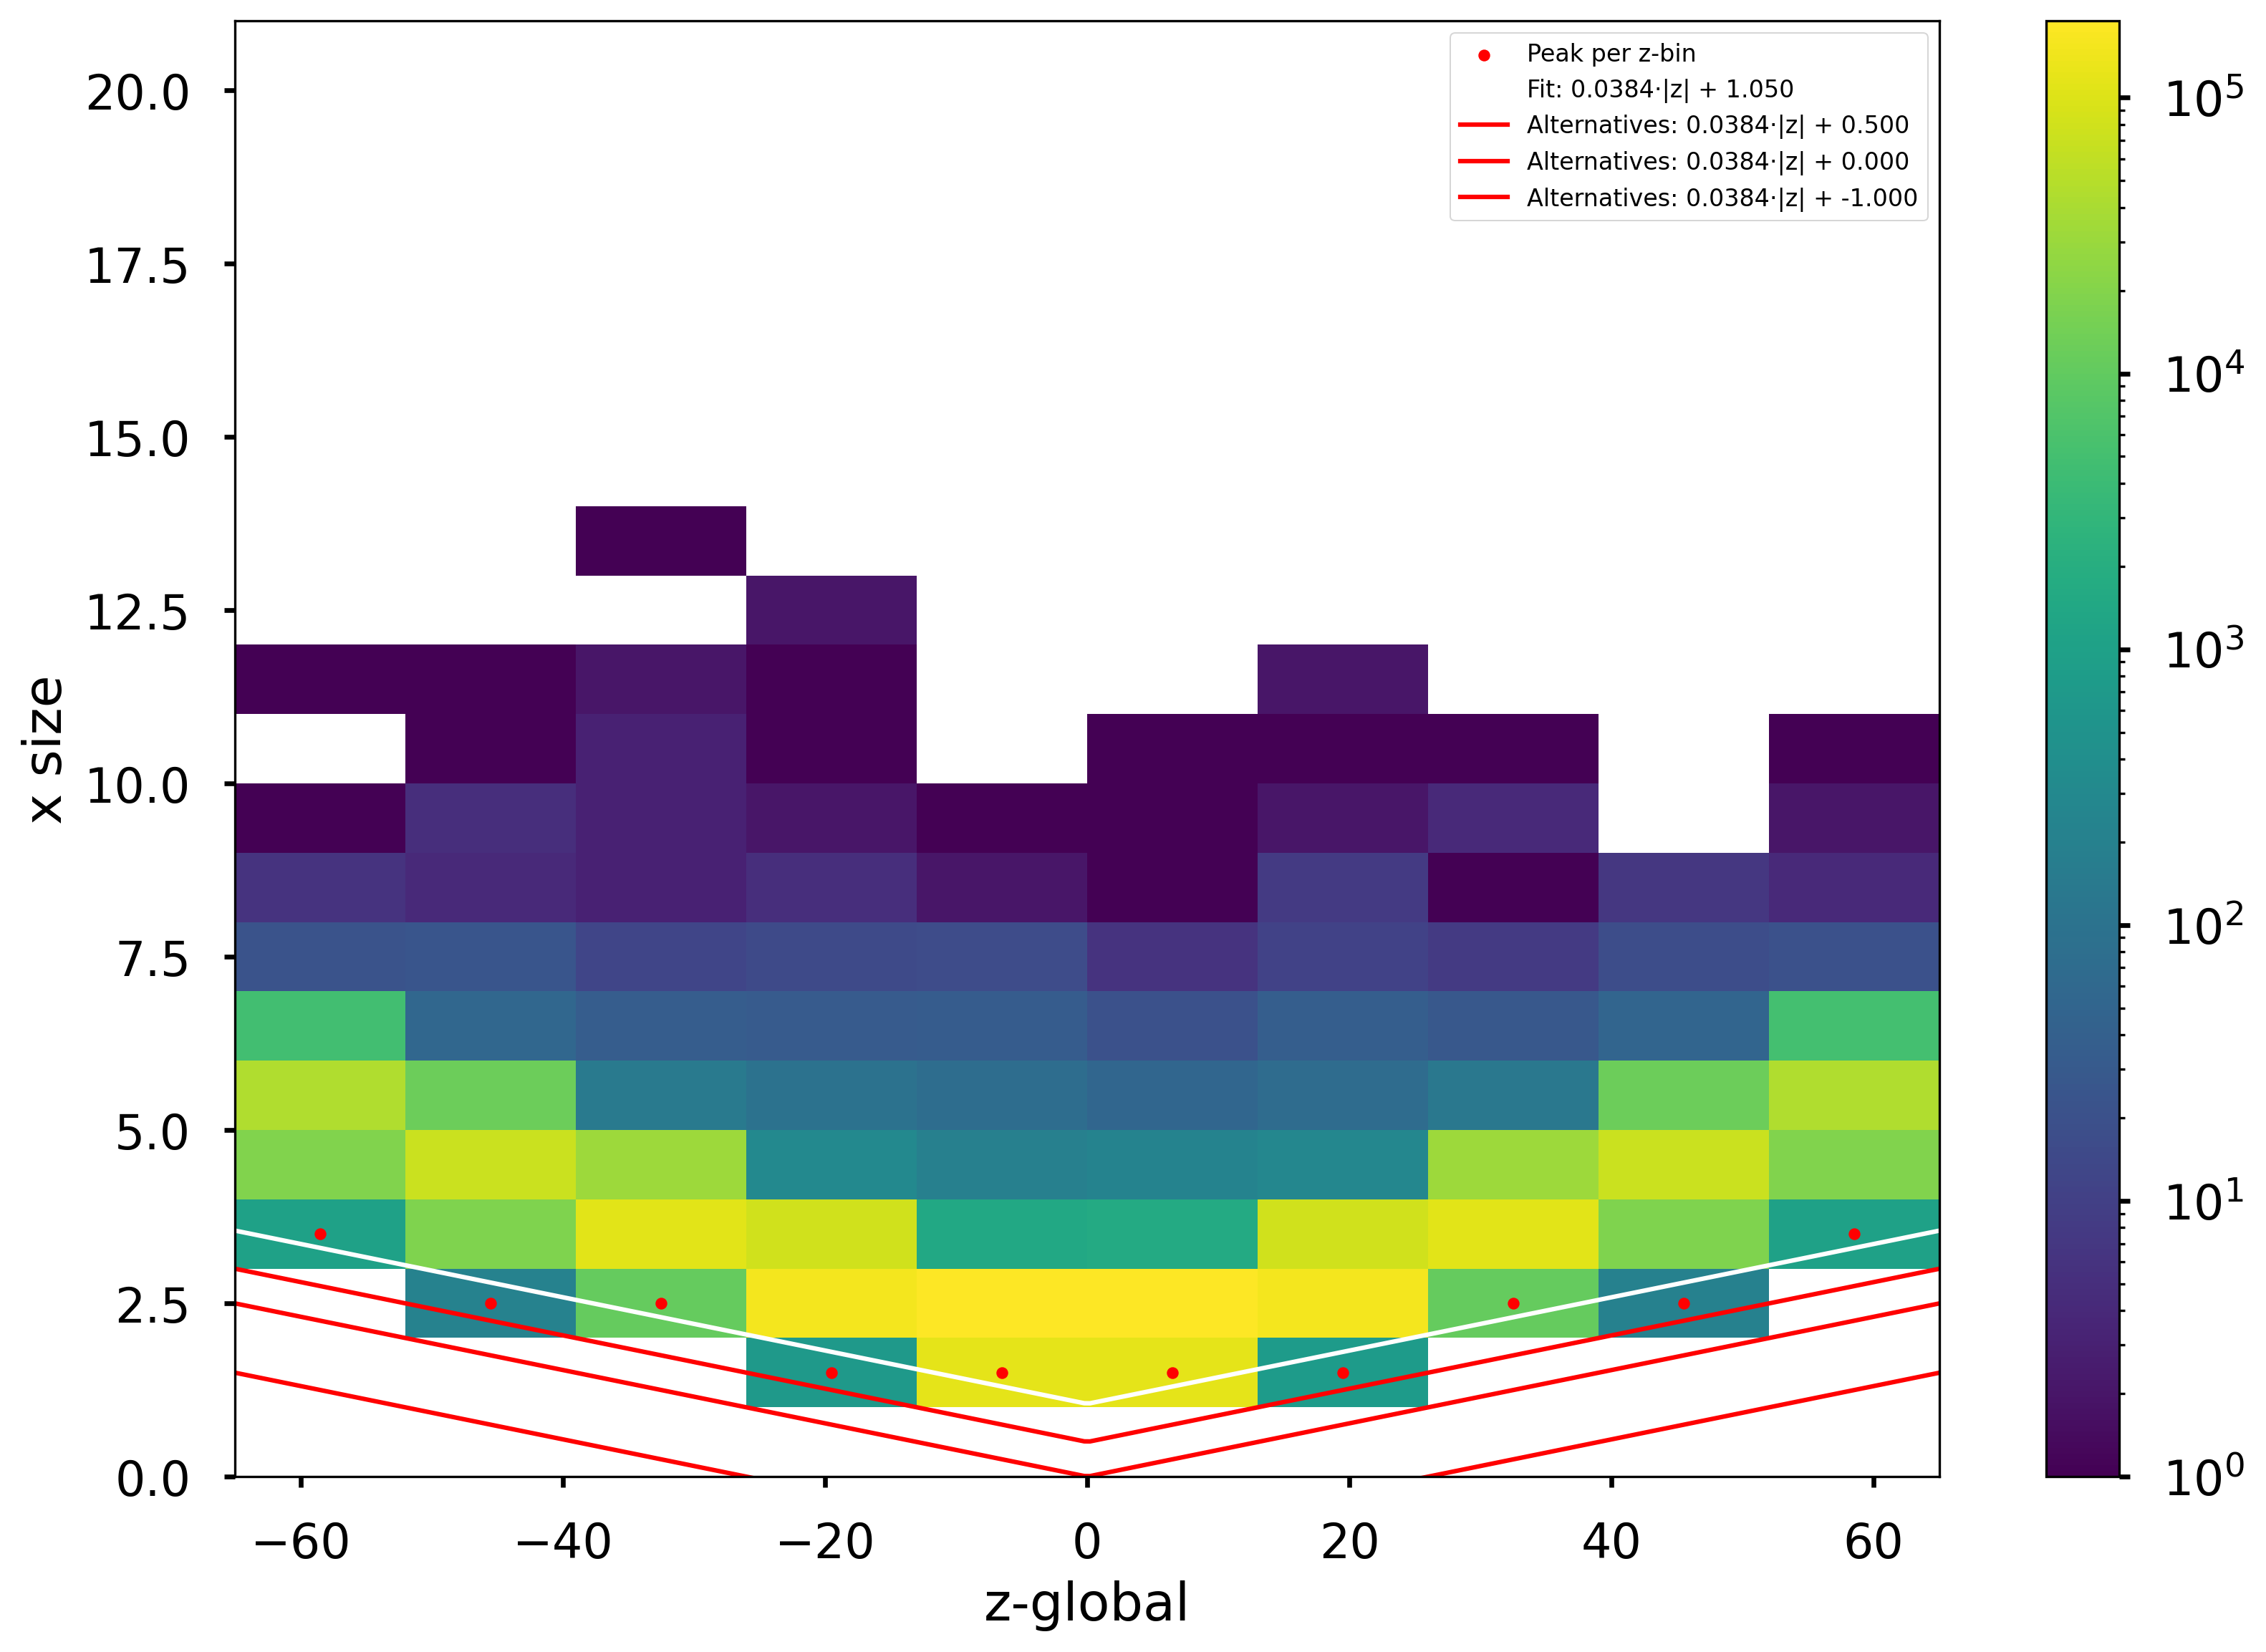

cut:  ((`z-global`<-52.0624973 and `z-global`>-65.074997 and xSize>=3.0) or (`z-global`<-39.0499976 and `z-global`>-52.0624973 and xSize>=2.0) or (`z-global`<-26.03749789999999 and `z-global`>-39.0499976 and xSize>=2.0) or (`z-global`<-13.024998199999992 and `z-global`>-26.03749789999999 and xSize>=1.0) or (`z-global`<-0.012498499999992418 and `z-global`>-13.024998199999992 and xSize>=1.0) or (`z-global`<13.000001200000014 and `z-global`>-0.012498499999992418 and xSize>=1.0) or (`z-global`<26.012500900000006 and `z-global`>13.000001200000014 and xSize>=1.0) or (`z-global`<39.02500060000001 and `z-global`>26.012500900000006 and xSize>=2.0) or (`z-global`<52.03750030000002 and `z-global`>39.02500060000001 and xSize>=2.0) or (`z-global`<65.05 and `z-global`>52.03750030000002 and xSize>=3.0)) and (nPix < 10)
number BIB clusters  1039136 number of signal clusters  1710521
fraction of total bib  0.6272491090485894  fraction of total signal  0.9961760819341128
cut:  (`z-global`<-52.0624973 an

In [105]:
slope, intercept, z_edges, z_centers, xsize_centers,peak_xsize,min_xsize = getCutConfig(plotter.truthSig,sizeKey="xSize",fitPeakLine=False,coordBins=10)
allCutRes = getAllCutConfigs(plotter.truthBib,plotter.truthSig,z_edges,min_xsize,slope,intercept,plotInitialDist=False,nCoarseIntercepts=19,nFineIntercepts=100)



[{'numBib': 1039136, 'numSig': 1710521, 'fracBib': 0.6272491090485894, 'fracSig': 0.9961760819341128, 'label': 'minxsizes per zglobal + nPix<10', 'cut': '((`z-global`<-52.0624973 and `z-global`>-65.074997 and xSize>=3.0) or (`z-global`<-39.0499976 and `z-global`>-52.0624973 and xSize>=2.0) or (`z-global`<-26.03749789999999 and `z-global`>-39.0499976 and xSize>=2.0) or (`z-global`<-13.024998199999992 and `z-global`>-26.03749789999999 and xSize>=1.0) or (`z-global`<-0.012498499999992418 and `z-global`>-13.024998199999992 and xSize>=1.0) or (`z-global`<13.000001200000014 and `z-global`>-0.012498499999992418 and xSize>=1.0) or (`z-global`<26.012500900000006 and `z-global`>13.000001200000014 and xSize>=1.0) or (`z-global`<39.02500060000001 and `z-global`>26.012500900000006 and xSize>=2.0) or (`z-global`<52.03750030000002 and `z-global`>39.02500060000001 and xSize>=2.0) or (`z-global`<65.05 and `z-global`>52.03750030000002 and xSize>=3.0)) and (nPix < 10)'}, {'numBib': 1245706, 'numSig': 171

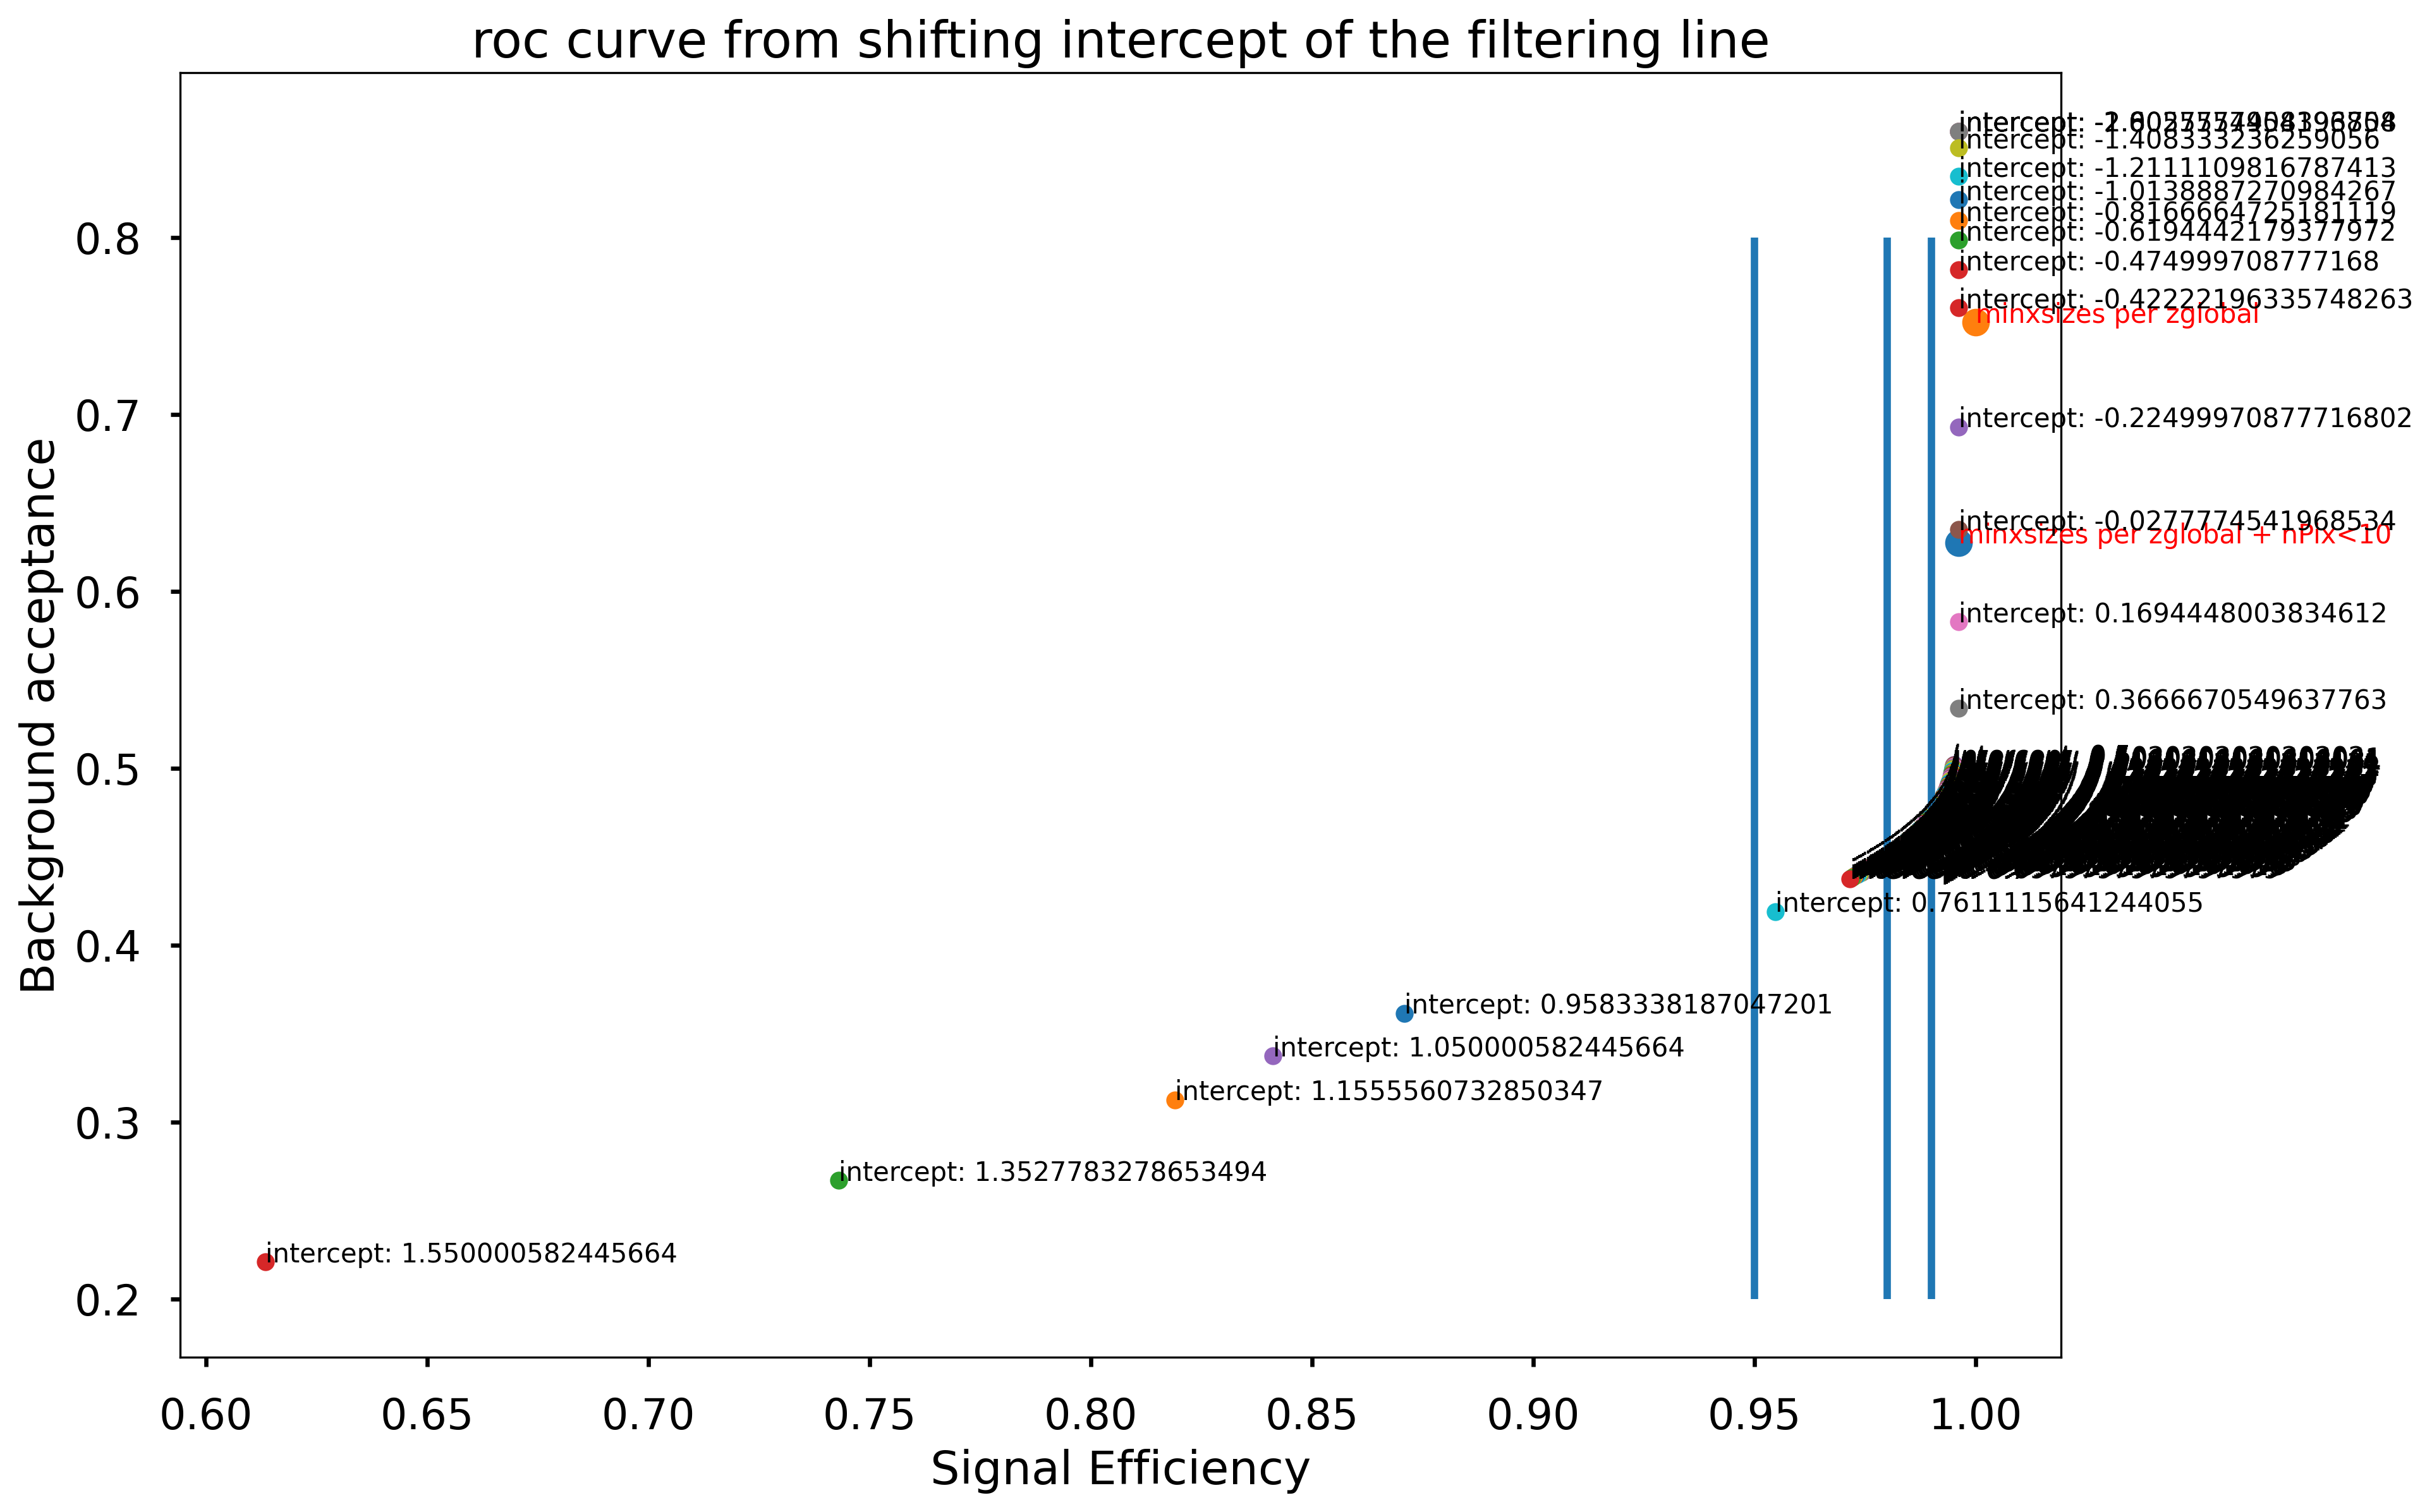

In [106]:
plotAllCutResRoc(allCutRes,sePoints=[0.95,0.98,0.99])
workingPoints = getWorkingPoints(allCutRes,sePoints=[0.95,0.98,0.99],addAllAcceptCutRes=True)


In [165]:
print(workingPoints[0][0])
print(workingPoints[0][1]["cut"])
def addWorkingPointPass(truthDf:pd.DataFrame,workingPoints,):
    truthDf = truthDf.copy()
    assert "nPix" in truthDf.keys()
    evalColNames = []
    for workingPoint in workingPoints:
        evalColName = f'BR_{workingPoint[0]["bRej"]:6f}__actSE_{workingPoint[0]["actualSE"]:6f}__targetSE_{workingPoint[0]["targetSE"]}'
        newCol=truthDf.eval(workingPoints[0][1]["cut"])
        truthDf[evalColName]=newCol
        evalColNames.append(evalColName)
    return truthDf,evalColNames

addedDf,_ = addWorkingPointPass(plotter.truthBib,workingPoints) 
print(addedDf.keys())
print([point[0]["targetSE"] for point in workingPoints])
print(workingPoints)

{'bRej': 0.5810898581238351, 'bAcc': 0.418910141876165, 'actualSE': 0.9548025231103607, 'targetSE': 0.95}
(nPix<10) and (xSize > `z-global`*0.038424574763933066 + 0.7611115641244055) and (xSize > `z-global`*-0.038424574763933066 + 0.7611115641244055)
Index(['x-entry', 'y-entry', 'z-entry', 'n_x', 'n_y', 'n_z', 'number_eh_pairs',
       'y-local', 'z-global', 'pt', 'hit_time', 'PID', 'cotAlpha', 'cotBeta',
       'y-midplane', 'x-midplane', 'adjusted_hit_time',
       'adjusted_hit_time_30ps_gaussian', 'adjusted_hit_time_60ps_gaussian',
       'source', 'eta', 'R', 'q', 'm', 'scalePion', 'p_calc1', 'p_calc2',
       'p_calc3', 'betaGamma', 'pathLength', 'EHperMicron', 'xSize', 'ySize',
       'nPix',
       'BR_0.5810898581238351__actSE_0.9548025231103607__targetSE_0.95',
       'BR_0.5493476014332487__actSE_0.9802852156006073__targetSE_0.98',
       'BR_0.526870394336543__actSE_0.9900971820297981__targetSE_0.99',
       'BR_0.581090__actSE_0.954803__targetSE_0.950000',
       'BR_0.549

In [175]:
def makePredVarDf(truthBib,truthSig,workingPoints):
    workingPoints = sorted(workingPoints, key=lambda point: point[0]["targetSE"],reverse=True)
    truthBib=truthBib.copy()
    truthSig=truthSig.copy()
    truthBib["trueY"] = 0
    truthSig["trueY"] = 1
    df = pd.concat([truthBib,truthSig])
    df, predCols = addWorkingPointPass(df,workingPoints)
    print(predCols)
    conditions = [df[predCol] for predCol in predCols]
    sePoints = [point[0]["targetSE"] for point in workingPoints]
    df["prediction"] = np.select(conditions, sePoints, default=0)


    for key in ["trueY","prediction","xSize","ySize","y-local","z-global",'eta']:
        assert key in df.keys()
    return df

predVarDf = makePredVarDf(plotter.truthBib,plotter.truthSig,workingPoints)

['BR_0.526870__actSE_0.990097__targetSE_0.99', 'BR_0.549348__actSE_0.980285__targetSE_0.98', 'BR_0.581090__actSE_0.954803__targetSE_0.95']


In [179]:
print(np.unique(predVarDf["prediction"]))
print(predVarDf.query("(`BR_0.526870__actSE_0.990097__targetSE_0.99`) and (not `BR_0.549348__actSE_0.980285__targetSE_0.98`)"))

[0.   0.99]
Empty DataFrame
Columns: [x-entry, y-entry, z-entry, n_x, n_y, n_z, number_eh_pairs, y-local, z-global, pt, hit_time, PID, cotAlpha, cotBeta, y-midplane, x-midplane, adjusted_hit_time, adjusted_hit_time_30ps_gaussian, adjusted_hit_time_60ps_gaussian, source, eta, R, q, m, scalePion, p_calc1, p_calc2, p_calc3, betaGamma, pathLength, EHperMicron, xSize, ySize, nPix, BR_0.5810898581238351__actSE_0.9548025231103607__targetSE_0.95, BR_0.5493476014332487__actSE_0.9802852156006073__targetSE_0.98, BR_0.526870394336543__actSE_0.9900971820297981__targetSE_0.99, BR_0.581090__actSE_0.954803__targetSE_0.950000, BR_0.549348__actSE_0.980285__targetSE_0.980000, BR_0.526870__actSE_0.990097__targetSE_0.990000, BR_0.581090__actSE_0.954803__targetSE_0.95, BR_0.549348__actSE_0.980285__targetSE_0.98, BR_0.526870__actSE_0.990097__targetSE_0.99, trueY, prediction]
Index: []

[0 rows x 45 columns]
